<a href="https://colab.research.google.com/github/muberragul/Fraud-Detection-and-Finance-Chatbot/blob/main/FraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fraud Detection In Money Transfers



## Problem Tanımı

Bankanın dijital kanalları (Mobil Şube ve İnternet Bankacılığı) üzerinden
gerçekleştirilen para transfer işlemlerinde, müşterinin bilgisi ve isteği dışında gerçekleşen sahte (fraudulent) işlemlerin gerçek zamanlı veya gerçek zamana yakın şekilde tespit edilmesi hedeflenmektedir.


**Beklenen Çıktılar:** Çalışma sonunda aşağıdaki çıktılar beklenmektedir:

• Bir para transfer işleminin fraud olup olmadığını tahmin eden makine öğrenmesi
modeli geliştirme kodları
• Girdi verilerini verdiğimizde model sonuçlarını veren çağrılabilir REST API  
• Çalışma kapsamında uygulanılan yöntem, araçlar ve elde edilen sonuçları
açıklayan teknik rapor  

Not: En az üç model üç farklı metrik ile karşılaştırılmalı ve elde edilen sonuçların analizi rapora eklenmelidir.

----

**Veri Kümesi**

• Satır sayısı: ~850K işlem

• Tarih aralığı: 2022-09 — 2024-09

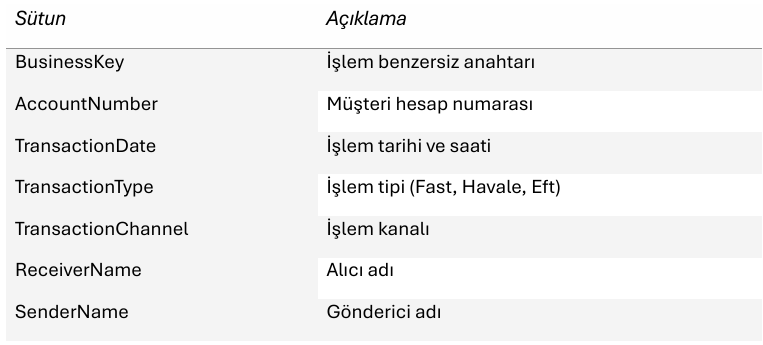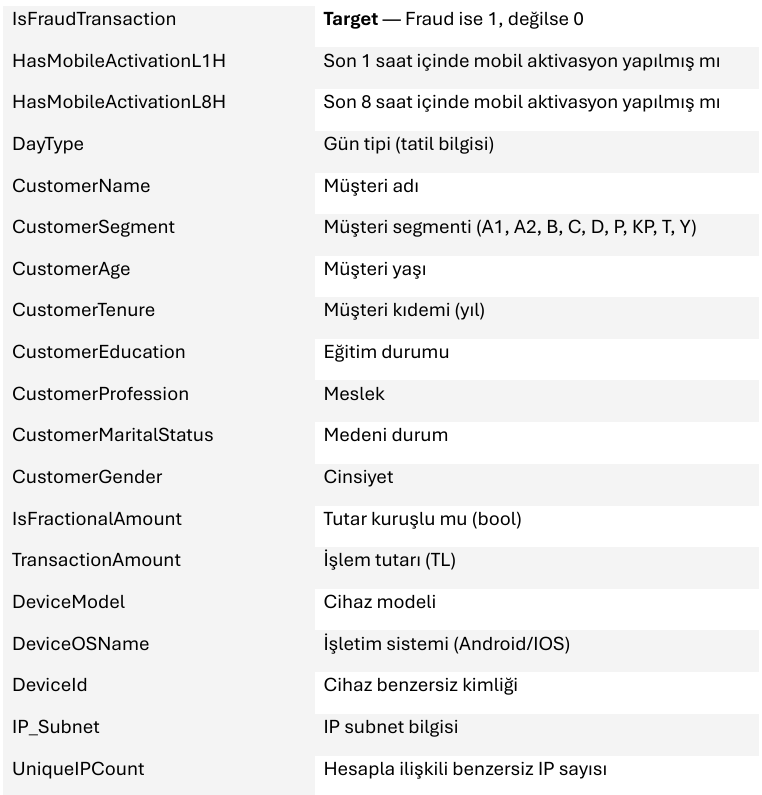

## Future Work

Model bu haliyle overfittir. Çözümü için:
- RecentSimilarTransactionsCount 1 saat gibi bir aralıktansa son 15dk'daki işlemler için güncellenecek
- Temizlenen veri tarihe göre sıralanıp örüntü yakalanabilir mi diye kontrol edilecek

# 1) Data Preprocessing / Veri Ön İşleme

En az değişken ile en fazla bilgiye ulaşmak istediğimizden veri incelenir ve temizlenir.

**A. Veri Setini İnceleme**

**B. Veri temizleme**

**C. Feature Engineering**

**D. Outlier Analizi & Scaling & Covariance**

Temizlenen veriden ilk feature'lar seçilir ve model eğitimine geçilir. Eğer sonuçlar istendiği şekilde olmazsa ileride feature seçimi değiştirilebilir.

## A. Veri Setini İnceleme

*   Veri seti genel olarak kolonlar, değerler, veri tipleri bakımından incelenir. Sahtecilik tespitinde faydalı olabilecek, kullanılmayacak, nümerik veriye dönüştürülmesi (encoding) gereken, null değerli vb. kolonlar hakkında çıkarımlar yapılır.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 30)

#veri seti yüklenip içeriği kontrol edilir
df = pd.read_parquet('synthetic_data.parquet')

print("\nVeri Seti Bilgisi:")
display(df.head())
df.info()


Veri Seti Bilgisi:


,BusinessKey,AccountNumber,TransactionDate,TransactionType,TransactionChannel,ReceiverName,SenderName,IsFraudTransaction,HasMobileActivationL1H,HasMobileActivationL8H,DayType,CustomerName,CustomerSegment,CustomerAge,CustomerTenure,CustomerEducation,CustomerProfession,CustomerMaritalStatus,CustomerGender,IsFractionalAmount,TransactionAmount,DeviceModel,DeviceOSName,DeviceId,IP_Subnet,UniqueIPCount
0,sdv-id-ydEjLE,99050379,2024-03-13 01:23:51.436705,Fast,Mobile,Uz. Neriban Mansız Aslan,Nades Paye Çorlu,0,0,0,None,Arş. Gör. Kerime Hurican Arslan İhsanoğlu,D,28,1.8,Lise,Komisyoncu,Evli,Erkek,False,679.768090,Redmi M2003J15SC,Android,88dcf57f3429e696,176.227.80,153
1,sdv-id-jsFUXw,98993243,2023-09-22 06:44:10.300229,Fast,Mobile,Aliihsan Şensoy,Torhan Efser Tarhan Çetin,0,0,0,None,Ertan Zengin,D,33,2.5,Yüksek Okul (2 Yıl),İşletmeci,Evli,Erkek,False,585.531211,samsung SM-A515F,Android,5f6b36e6dca77cfb,95.70.245,81
2,sdv-id-OcGttJ,70926720,2024-04-03 20:36:52.256274,Fast,Mobile,Bayan Perinur Dilfeza Durmuş Akçay,Nejdet Zorlu Akar,0,0,0,None,Av. Sevican Havse Sakarya,P,40,5.7,Lise,İşçi,Evli,Erkek,False,19541.774129,samsung SM-A405FN,IOS,1ebad3a81ee95a68,178.244.13,129
3,sdv-id-LqWsUp,5190402,2024-09-10 05:01:29.879912,Fast,Mobile,Bağdat Arsoy,Dr. Tükelalp Sakarya,0,0,0,None,Uz. Sabih Koşukhan Şafak,D,40,8.4,Lise,İşçi,Bekar,Kadın,False,20493.348828,"iPhone15,3",Android,89B0B896-DBDE-4BA8-95A1-4EB6AD92378A,78.173.111,94
4,sdv-id-thcieX,67812033,2022-10-13 00:08:59.050459,Fast,Mobile,Toker Akdora Ergül Yılmaz,Ülküm Divan Ertaş,0,0,0,None,Kitan Çorlu,B,36,5.9,Fakülte (4 Yıl),İşçi,Evli,Erkek,False,45737.080849,samsung SM-A105F,Android,8d2b00c4d5025f14,94.235.247,79


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 849564 entries, 0 to 849563
Data columns (total 26 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   BusinessKey             849564 non-null  object        
 1   AccountNumber           849564 non-null  int64         
 2   TransactionDate         849564 non-null  datetime64[ns]
 3   TransactionType         849564 non-null  object        
 4   TransactionChannel      849564 non-null  object        
 5   ReceiverName            849564 non-null  object        
 6   SenderName              849564 non-null  object        
 7   IsFraudTransaction      849564 non-null  int64         
 8   HasMobileActivationL1H  849564 non-null  int64         
 9   HasMobileActivationL8H  849564 non-null  int64         
 10  DayType                 30481 non-null   object        
 11  CustomerName            849564 non-null  object        
 12  CustomerSegment         849564

*   Genel veri seti kontrol edildikten sonra sahtecilik işlemlerini anlamak için IsFraudTransaction'ı 1 olan satırlar filtrelenip incelenir. Önemli olabilecek kolonlar hakkında fikir yürütülür ve kolonların değerleri incelenir. Bu çıkarımlar feature seçilirken kullanılır.
    *   Geçersiz cihaz modelleri (KUVEYT TURK KATILIM BANKASI ÇEKİLİŞ ONAY, KUVEYT TURK KATILIM BANKASI CAGRI MERKEZI) bulunmakta.
    *   IP_Subnet'i aynı olan (91.151.xxx, 178.240.xxx) işlemlerde sahtecilik görülmüş.
    *   Unique IP count'u düşük işlemler fraud olmaya yakın olabilir.
    *   CustomerTenure önemli olabilir yüksekse fraud olmayabilir.

In [ ]:
# Fraud işlemlerini anlamak için IsFraudTransaction'ı 1 olan satırlar filtrelenerek incelenir

fraud_transactions = df[df['IsFraudTransaction'] == 1]

print("\nFraud İşlemleri (IsFraudTransaction == 1):")
display(fraud_transactions.head())
print(f"Toplam fraud işlemi: {len(fraud_transactions)}")


Fraud İşlemleri (IsFraudTransaction == 1):


,BusinessKey,AccountNumber,TransactionDate,TransactionType,TransactionChannel,ReceiverName,SenderName,IsFraudTransaction,HasMobileActivationL1H,HasMobileActivationL8H,DayType,CustomerName,CustomerSegment,CustomerAge,CustomerTenure,CustomerEducation,CustomerProfession,CustomerMaritalStatus,CustomerGender,IsFractionalAmount,TransactionAmount,DeviceModel,DeviceOSName,DeviceId,IP_Subnet,UniqueIPCount
844226,sdv-id-apKAXN,17426023,2023-08-04 11:33:16.275523,Fast,Mobile,Bayan Nevsale Rebihat Çamurcuoğlu,Nerim Demir,1,0,0,None,Bayan Şamiha Temime Yılmaz Demir,D,44,12.1,Fakülte (4 Yıl),İşçi,Evli,Erkek,False,1341.365861,KUVEYT TURK KATILIM BANKASI ÇEKİLİŞ ONAY,Android,6cfc3768d822a20f,91.151.136,42
844227,sdv-id-PjYqeg,19724949,2023-10-08 13:13:40.952791,Fast,Mobile,Öğr. Aytek Öcalan,Basriye Yüksel,1,0,0,None,Çev. Kuddusi Tanhan Akçay,B,59,11.0,Fakülte (4 Yıl),İşletmeci,Evli,Erkek,False,1385.225159,Redmi 22101316I,IOS,5023a7497f25c151,194.165.161,90
844228,sdv-id-HNLcbe,53515843,2023-10-03 20:59:54.822532,Havale,Mobile,Doç. Salami Nebih Bilge,Dr. Masume Meryeme Yıldırım,1,0,0,None,Korkmazalp Gül,B,37,5.2,Yüksek Okul (2 Yıl),Ev Hanımı,Evli,Kadın,False,15108.554972,iPhone 7,Android,5facaaa27b5053fa,91.151.138,91
844229,sdv-id-iyPFgP,90226904,2023-05-18 04:26:37.229572,Fast,Mobile,Kadınana Teybet Yüksel Seven,Gazel Akar,1,0,0,None,Rafih Türk,C,39,1.6,Fakülte (4 Yıl),Memur,Bekar,Kadın,True,19797.827287,iPhone 11,Android,a483bd0af3c1df2a,91.151.137,3
844230,sdv-id-CIqaVW,46864095,2024-05-29 12:39:50.821892,Fast,Mobile,Ahter Divan Şama,Öğr. Damlanur Akça Yıldırım,1,0,0,None,Öğr. Aynımah Menişan Sezer Gülen,B,66,6.5,None,Çiftçi,Evli,Erkek,True,57868.740901,google sdk_gphone64_arm64,Android,1212ba7daaa67214,178.240.176,167


Toplam fraud işlemi: 5338


In [ ]:
columnsToInspect = [
    'TransactionChannel',
    'CustomerEducation',
    'CustomerProfession',
    'CustomerMaritalStatus',
    'DeviceModel',
    'DeviceId',
    'DayType',
    'IsFractionalAmount'
]

print(f"\n--- Tüm İşlemler ---")
for col in columnsToInspect:
    print(f"\n--- {col} kolonunun içerdiği değerler ---")
    display(df[col].value_counts())

print(f"\n--- Fraud İşlemleri ---")
# fraud işlemleri içinde de grupların dağılımları incelenir
for col in columnsToInspect:
    print(f"\n--- fraud durumunda {col} kolonunun içerdiği değerler ---")
    display(fraud_transactions[col].value_counts())


--- Tüm İşlemler ---

--- TransactionChannel kolonunun içerdiği değerler ---


,count
TransactionChannel,
Mobile,849564



--- CustomerEducation kolonunun içerdiği değerler ---


,count
CustomerEducation,
Lise,316546
Fakülte (4 Yıl),293335
İlköğretim,103328
Yüksek Okul (2 Yıl),49224
Yüksek Lisans,47880
Doktora,13980
Okur-Yazar,8400
Okul Öncesi,1938
Okumuyor,801



--- CustomerProfession kolonunun içerdiği değerler ---


...

,count
DeviceId,
194f3cebb022e932,113
3bb026ee90314fd5,100
a0561eccaeb5d037,83
2a77f1808b7ef6ff,80
6303e6933431e6f5,77
...,...
fcc711f386c0b158,1
85EBC163-054C-4365-927E-85A73C3D27AC,1
4080eb8b3b151617,1



--- fraud durumunda DayType kolonunun içerdiği değerler ---


,count
DayType,
Resmi Tatil,185
Yarım Gün Resmi Tatil,10



--- fraud durumunda IsFractionalAmount kolonunun içerdiği değerler ---


,count
IsFractionalAmount,
False,3233
True,2105


In [ ]:
print(f"Minimum Customer Age: {df['CustomerAge'].min()}")
print(f"Maximum Customer Age: {df['CustomerAge'].max()}")

# Also displaying a quick distribution summary
display(df['CustomerAge'].describe())

Minimum Customer Age: 18
Maximum Customer Age: 89


,CustomerAge
count,849564.000000
mean,39.897719
std,10.745581
min,18.000000
25%,32.000000
50%,39.000000
75%,47.000000
max,89.000000


*   Verideki bazı tutarsızlıklar ve pattern'lar tespit edilse de birçoğu sentetik veriden kaynaklı görülüp değerlendirmeye alınmaz.

    *   Alıcı adındaki unvanla alıcı meslekleri uyuşmamakta. Alıcı adı ve cinsiyet uyuşmamakta. Eğitim bilgisi ve meslek uyuşmamakta (lise mezunu diş hekimi vb.).
    *   Bu tarz tutarsızlıklar veriyi gruplamadaki seçimleri etkiler. Örneğin normalde gelir düzeyi ile gruplanabilirken sıklığa göre gruplama tercih edildi.

## B. Veri temizleme

  *   Unique veriler ve NLP/LLM kullanılmadan anlamlandıramayacağımız -bu görev özelinde sentetik üretildiğinden zaten anlamsız olan- veriler (`BusinessKey`, `ReceiverName`, `SenderName`, `CustomerName`) temizlenir. Tek değer içeren `TransactionChannel` kolonu da temizlenir.

In [ ]:
droppedColumns = ['BusinessKey', 'ReceiverName', 'SenderName', 'CustomerName', 'TransactionChannel']

df = df.drop(columns=droppedColumns)
print("Kolonlar temizlendi.")

print(df.columns)

Kolonlar temizlendi.
Index(['AccountNumber', 'TransactionDate', 'TransactionType',
       'IsFraudTransaction', 'HasMobileActivationL1H',
       'HasMobileActivationL8H', 'DayType', 'CustomerSegment', 'CustomerAge',
       'CustomerTenure', 'CustomerEducation', 'CustomerProfession',
       'CustomerMaritalStatus', 'CustomerGender', 'IsFractionalAmount',
       'TransactionAmount', 'DeviceModel', 'DeviceOSName', 'DeviceId',
       'IP_Subnet', 'UniqueIPCount'],
      dtype='object')


In [ ]:
df.isnull().sum()

,0
AccountNumber,0
TransactionDate,0
TransactionType,0
IsFraudTransaction,0
HasMobileActivationL1H,0
HasMobileActivationL8H,0
DayType,819083
CustomerSegment,0
CustomerAge,0
CustomerTenure,0


  *   Null veriler içeren kolonlar incelenir.
      *   `DayType` için resmi tatil olma bilgisi nümerikleştirilerek null handling yapılır.
      *   `CustomerMaritalStatus`'te null değerler gözardı edilebilecek kadar az (188/849564) olduğu için bu satırlar temizlenir.
      *   `CustomerEducation` ordinal encoding ile eğitim basamaklarına göre nümerikleştirildikten sonra null kayıtlara ortalama eğitim değeri atanır.

In [ ]:
# Null handling

# DayType ve CustomerEducation encode edilecektir.
# CustomerMaritalStatus'te null değerler gözardı edilebilecek kadar az olduğu ve fraud işlem içermediği için bu satırlar temizlenir.
df = df.dropna(subset=['CustomerMaritalStatus'])

  *   Encoding ile kategorik veriler nümerikleştirilir.
      *   `CustomerSegment`, `TransactionType`, `DeviceOSName`, `DayType`, `IsFractionalAmount`, `CustomerEducation` kolonlarının değerleri bilindiğinden ve sıralı olduğundan kolonlar ordinal encoding ile nümerikleştirilir.
      *   `CustomerMaritalStatus`, `CustomerGender`,`CustomerProfession` (gruplandıktan sonra), `CustomerAge` (binning sonrası) one-hot encoding ile nümerikleştirilir.

In [ ]:
# Ordinal Encoding

# CustomerSegment için müşterinin önemine göre ordinal encoding yapılır
segment_mapping = {
    'A1': 0, 'A2': 1, 'B': 2, 'C': 3, 'D': 4,
    'P': 5, 'KP': 6, 'T': 7, 'Y': 8
}
df['CustomerSegment_Encoded'] = df['CustomerSegment'].map(segment_mapping)

print("Ordinal encoding sonrası CustomerSegment:")
display(df[['CustomerSegment', 'CustomerSegment_Encoded']].head())

# TransactionType ve DeviceOSName değerleri bilindiği için nümerik olarak map'lenirler.
transaction_type_mapping = {
    'Fast': 0,
    'Havale': 1,
    'Eft': 2
}
df['TransactionType_Encoded'] = df['TransactionType'].map(transaction_type_mapping)

print("\nEncoding sonrası TransactionType:")
display(df[['TransactionType', 'TransactionType_Encoded']].head())

daytype_mapping = {
    None: 0, # None (null) 0'a map'lenir
    'Yarım Gün Resmi Tatil': 1,
    'Resmi Tatil': 2
}
df['DayType_Encoded'] = df['DayType'].map(daytype_mapping)

print("\nEncoding sonrası DayType:")
display(df[['DayType', 'DayType_Encoded']].head())

device_os_mapping = {
    'IOS': 0,
    'Android': 1
}
df['IsDeviceOSAndroid'] = df['DeviceOSName'].map(device_os_mapping)

print("\nEncoding sonrası DeviceOSName:")
display(df[['DeviceOSName', 'IsDeviceOSAndroid']].head())

# IsFractionalAmount için bool int'e çevrilir
df['IsFractionalAmount'] = df['IsFractionalAmount'].astype(int)

print("\nEncoding sonrası IsFractionalAmount:")
display(df['IsFractionalAmount'].head())

# CustomerEducation için encoding öncesi null handling yapılır
df['CustomerEducation'] = df['CustomerEducation'].fillna('Unknown')
# CustomerEducation için eğitim basamaklarına göre ordinal encoding yapılır
education_mapping = {
    'Unknown': 0,
    'Okumuyor': 1,
    'Okul Öncesi': 2,
    'Okur-Yazar': 3,
    'İlköğretim': 4,
    'Lise': 5,
    'Yüksek Okul (2 Yıl)': 6,
    'Fakülte (4 Yıl)': 7,
    'Yüksek Lisans': 8,
    'Doktora': 9
}
df['CustomerEducation_Encoded'] = df['CustomerEducation'].map(education_mapping)

# CustomerEducation_Encoded'ın ortalaması bulunur ve 0 olarak map'lenmiş null değerlere verilir
mean_education_level = df[df['CustomerEducation_Encoded'] != 0]['CustomerEducation_Encoded'].mean()
df['CustomerEducation_Encoded'] = df['CustomerEducation_Encoded'].replace(0, mean_education_level).round().astype(int)

print("\nOrdinal encoding sonrası CustomerEducation:")
display(df[['CustomerEducation', 'CustomerEducation_Encoded']].head())

Ordinal encoding sonrası CustomerSegment:


,CustomerSegment,CustomerSegment_Encoded
0,D,4
1,D,4
2,P,5
3,D,4
4,B,2



Encoding sonrası TransactionType:


,TransactionType,TransactionType_Encoded
0,Fast,0
1,Fast,0
2,Fast,0
3,Fast,0
4,Fast,0



Encoding sonrası DayType:


...

,DeviceOSName,IsDeviceOSAndroid
0,Android,1
1,Android,1
2,IOS,0
3,Android,1
4,Android,1



Encoding sonrası IsFractionalAmount:


,IsFractionalAmount
0,0
1,0
2,0
3,0
4,0



Ordinal encoding sonrası CustomerEducation:


,CustomerEducation,CustomerEducation_Encoded
0,Lise,5
1,Yüksek Okul (2 Yıl),6
2,Lise,5
3,Lise,5
4,Fakülte (4 Yıl),7


In [ ]:
# One-hot encoding

# Nümerik/encode işleminden geçmiş (feature engineering yapılacaklar harici) direkt kopyalanır
finalFeatures = [
    'AccountNumber',
    'IsFraudTransaction',
    'HasMobileActivationL1H',
    'HasMobileActivationL8H',
    'CustomerAge',
    'CustomerTenure',
    'TransactionAmount',
    'IP_Subnet',
    'UniqueIPCount',
    'CustomerSegment_Encoded',
    'TransactionType_Encoded',
    'DayType_Encoded',
    'IsDeviceOSAndroid',
    'IsFractionalAmount',
    'CustomerEducation_Encoded'
]

# df feature engineering için orijinal olarak korunur, temizlenen veriler df_encoded'a kopyalanır
df_encoded = df[finalFeatures].copy()

# One-hot encoding ile üretilen sütunlar df_encoded'a eklenir
categoricalColumns = [
    'CustomerMaritalStatus',
    'CustomerGender'
]
df_ohe = pd.get_dummies(df[categoricalColumns], columns=categoricalColumns, drop_first=True, dtype=int)
df_encoded = pd.concat([df_encoded, df_ohe], axis=1)

print("One-Hot Encoding sonrası:")
display(df_encoded.head())
df_encoded.info()

One-Hot Encoding sonrası:


,AccountNumber,IsFraudTransaction,HasMobileActivationL1H,HasMobileActivationL8H,CustomerAge,CustomerTenure,TransactionAmount,IP_Subnet,UniqueIPCount,CustomerSegment_Encoded,TransactionType_Encoded,DayType_Encoded,IsDeviceOSAndroid,IsFractionalAmount,CustomerEducation_Encoded,CustomerMaritalStatus_Bosanmis,CustomerMaritalStatus_Dul,CustomerMaritalStatus_Evli,CustomerGender_Kadın
0,99050379,0,0,0,28,1.8,679.768090,176.227.80,153,4,0,0,1,0,5,0,0,1,0
1,98993243,0,0,0,33,2.5,585.531211,95.70.245,81,4,0,0,1,0,6,0,0,1,0
2,70926720,0,0,0,40,5.7,19541.774129,178.244.13,129,5,0,0,0,0,5,0,0,1,0
3,5190402,0,0,0,40,8.4,20493.348828,78.173.111,94,4,0,0,1,0,5,0,0,0,1
4,67812033,0,0,0,36,5.9,45737.080849,94.235.247,79,2,0,0,1,0,7,0,0,1,0


<class 'pandas.core.frame.DataFrame'>
Index: 849376 entries, 0 to 849563
Data columns (total 19 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   AccountNumber                   849376 non-null  int64  
 1   IsFraudTransaction              849376 non-null  int64  
 2   HasMobileActivationL1H          849376 non-null  int64  
 3   HasMobileActivationL8H          849376 non-null  int64  
 4   CustomerAge                     849376 non-null  int64  
 5   CustomerTenure                  849376 non-null  float64
 6   TransactionAmount               849376 non-null  float64
 7   IP_Subnet                       849376 non-null  object 
 8   UniqueIPCount                   849376 non-null  int64  
 9   CustomerSegment_Encoded         849376 non-null  int64  
 10  TransactionType_Encoded         849376 non-null  int64  
 11  DayType_Encoded                 849376 non-null  int64  
 12  IsDeviceOSAndroid    

## C. Feature Engineering

  *   `CustomerProfession` 100+ farklı değer içerdiği için one-hot encoding öncesi gruplanır.
      *   Gruplama stratejisi gerçek hayatta gelir düzeyine göre yapılabilir ancak sentetik veride tercih edilmemiştir.
      *   İlk yöntem olarak en sık geçen N grup ve 'other' olarak gruplanır. Sonuçlara göre N değeri değiştirilebilir. Overfitting'i önlemek amacıyla yüksek N değerleri tercih edilmez.
      *   Overfitting riski nedeniyle Target Encoding tercih edilmemiştir. Sonuçlara göre ileride uygulanabilir.

In [ ]:
# CustomerProfession gruplama ve one-hot encoding

# 100+ başlık barındırdığı için en çok sahip olunan meslekler ve diğerleri olarak gruplanır.
TOP_N_PROFESSIONS = 10

top_professions = df['CustomerProfession'].value_counts().head(TOP_N_PROFESSIONS).index.tolist()

# Top N meslek dışındakiler other olarak gruplanır
df_encoded['CustomerProfession_Grouped'] = df['CustomerProfession'].apply(lambda x: x if x in top_professions else 'Other')

display(df_encoded['CustomerProfession_Grouped'].value_counts())
# Concat yapılmadan rerun durumundan oluşabilecek duplikeler temizlenir
existing_profession_ohe_cols = [col for col in df_encoded.columns if col.startswith('CustomerProfession_') and col != 'CustomerProfession_Grouped']
if existing_profession_ohe_cols:
    df_encoded = df_encoded.drop(columns=existing_profession_ohe_cols)

# One-hot encoding
df_profession_ohe = pd.get_dummies(df_encoded['CustomerProfession_Grouped'], prefix='CustomerProfession', drop_first=True, dtype=int)
df_encoded = pd.concat([df_encoded, df_profession_ohe], axis=1)

df_encoded = df_encoded.drop(columns=['CustomerProfession_Grouped'])

print("\n CustomerProfession One-Hot Encoding sonrası:")
display(df_encoded.head())

,count
CustomerProfession_Grouped,
Other,294029
İşçi,175292
İşletmeci,111313
Pazarlamacı/Satış Elemanı,56548
Ev Hanımı,42744
Mühendis,38220
Muhasebeci,34652
Öğretmen,31194
Öğrenci,23674



 CustomerProfession One-Hot Encoding sonrası:


,AccountNumber,IsFraudTransaction,HasMobileActivationL1H,HasMobileActivationL8H,CustomerAge,CustomerTenure,TransactionAmount,IP_Subnet,UniqueIPCount,CustomerSegment_Encoded,TransactionType_Encoded,DayType_Encoded,IsDeviceOSAndroid,IsFractionalAmount,CustomerEducation_Encoded,CustomerMaritalStatus_Bosanmis,CustomerMaritalStatus_Dul,CustomerMaritalStatus_Evli,CustomerGender_Kadın,CustomerProfession_Ev Hanımı,CustomerProfession_Memur,CustomerProfession_Muhasebeci,CustomerProfession_Mühendis,CustomerProfession_Other,CustomerProfession_Pazarlamacı/Satış Elemanı,CustomerProfession_Öğrenci,CustomerProfession_Öğretmen,CustomerProfession_İşletmeci,CustomerProfession_İşçi
0,99050379,0,0,0,28,1.8,679.768090,176.227.80,153,4,0,0,1,0,5,0,0,1,0,0,0,0,0,1,0,0,0,0,0
1,98993243,0,0,0,33,2.5,585.531211,95.70.245,81,4,0,0,1,0,6,0,0,1,0,0,0,0,0,0,0,0,0,1,0
2,70926720,0,0,0,40,5.7,19541.774129,178.244.13,129,5,0,0,0,0,5,0,0,1,0,0,0,0,0,0,0,0,0,0,1
3,5190402,0,0,0,40,8.4,20493.348828,78.173.111,94,4,0,0,1,0,5,0,0,0,1,0,0,0,0,0,0,0,0,0,1
4,67812033,0,0,0,36,5.9,45737.080849,94.235.247,79,2,0,0,1,0,7,0,0,1,0,0,0,0,0,0,0,0,0,0,1


  *   İlk incelemelerde `DeviceModel` içerisindeki geçersiz/yanıltıcı stringlerin fraud ile bağlantılı olduğu görülmüştü. Bu çıkarımlar `IsFlaggedDeviceModel` ile nümerikleştirilir. Bazı business mantıklı (bankanın ismini geçiren) stringleri içermesi *veya* geçerli bir cihaz modeli adından uzun olması durumunda kayıt flag'lenir.

In [ ]:
# DeviceModel ve IsFlaggedDeviceModel

# Fraud işlemlerinde kullanıldığından şüphelenilen cihaz modeli olamayacak bazı keyword'lerin listesi tutulur
suspectDeviceKeywords = [
    'KUVEYT TURK KATILIM BANKASI',
    'KUVEYTTÜRK',
    'KUVEYTTURK',
    'ONAY',
    'KAMPANYA',
    'KREDİ',
    '?'
]
suspectDeviceKeywordsLower = [k.lower() for k in suspectDeviceKeywords]

# Gerçek olmayan cihaz modellerinde uzun stringler tespit edilmiştir, dolayısıyla length de kontrol edilir
DEVICE_MODEL_LENGTH_THRESHOLD = 35

# İşlemin flaglenebilmesi için keywordlere veya uzunluğa bakılır
df['IsFlaggedDeviceModel'] = df['DeviceModel'].str.lower().apply(
    lambda x: 1 if any(keyword in x for keyword in suspectDeviceKeywordsLower) or len(x) > DEVICE_MODEL_LENGTH_THRESHOLD else 0
)

print("IsFlaggedDeviceModel feature izlenimi:")
display(df[['DeviceModel', 'IsFlaggedDeviceModel']].head())

df_encoded['IsFlaggedDeviceModel'] = df['IsFlaggedDeviceModel']
display(df_encoded.head())

print("\nFlag'lenen örnekler:")
display(df[df['IsFlaggedDeviceModel'] == 1]['DeviceModel'].value_counts().head(20))

IsFlaggedDeviceModel feature izlenimi:


,DeviceModel,IsFlaggedDeviceModel
0,Redmi M2003J15SC,0
1,samsung SM-A515F,0
2,samsung SM-A405FN,0
3,"iPhone15,3",0
4,samsung SM-A105F,0


,AccountNumber,IsFraudTransaction,HasMobileActivationL1H,HasMobileActivationL8H,CustomerAge,CustomerTenure,TransactionAmount,IP_Subnet,UniqueIPCount,CustomerSegment_Encoded,TransactionType_Encoded,DayType_Encoded,IsDeviceOSAndroid,IsFractionalAmount,CustomerEducation_Encoded,CustomerMaritalStatus_Bosanmis,CustomerMaritalStatus_Dul,CustomerMaritalStatus_Evli,CustomerGender_Kadın,CustomerProfession_Ev Hanımı,CustomerProfession_Memur,CustomerProfession_Muhasebeci,CustomerProfession_Mühendis,CustomerProfession_Other,CustomerProfession_Pazarlamacı/Satış Elemanı,CustomerProfession_Öğrenci,CustomerProfession_Öğretmen,CustomerProfession_İşletmeci,CustomerProfession_İşçi,IsFlaggedDeviceModel
0,99050379,0,0,0,28,1.8,679.768090,176.227.80,153,4,0,0,1,0,5,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0
1,98993243,0,0,0,33,2.5,585.531211,95.70.245,81,4,0,0,1,0,6,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0
2,70926720,0,0,0,40,5.7,19541.774129,178.244.13,129,5,0,0,0,0,5,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
3,5190402,0,0,0,40,8.4,20493.348828,78.173.111,94,4,0,0,1,0,5,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
4,67812033,0,0,0,36,5.9,45737.080849,94.235.247,79,2,0,0,1,0,7,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0



Flag'lenen örnekler:


,count
DeviceModel,
KUVEYT TURK KATILIM BANKASI ÇEKİLİŞ ONAY,359
Kuveyt Türk Katılım Bankası Çekiliş Onay,122
KUVEYTTÜRK KATILIM BANKASI KREDİ SORGULAMA,122
Kuveyt Çekiliş Katılım Kuveyt Çekiliş Bildirim Ona,86
KUVEYT TÜRK KATILIM BANKASI ÇEKİLİŞ ONAY,86
KUVEYT TÜRK KATILIM BANKASI GÜVENLİK BİLDİRİM ONAY,65
KUVEYTTURK ONAY VERINIZ,63
KUVEYT TÜRK KATILIM BANK GÜVENLİK BİLDİRİM ONAY,62
kuveytturk onay verınız,59


  *   Pattern tespiti amacıyla `TransactionDate` saat, haftanın günü ve ay olarak ayrılır.

In [ ]:
df_encoded['Transaction_hour'] = df['TransactionDate'].dt.hour
df_encoded['Transaction_day_of_week'] = df['TransactionDate'].dt.dayofweek
df_encoded['Transaction_month'] = df['TransactionDate'].dt.month

print("TransactionDate ayrılması sonrasında df_encoded:")
display(df_encoded.head())

TransactionDate ayrılması sonrasında df_encoded:


,AccountNumber,IsFraudTransaction,HasMobileActivationL1H,HasMobileActivationL8H,CustomerAge,CustomerTenure,TransactionAmount,IP_Subnet,UniqueIPCount,CustomerSegment_Encoded,TransactionType_Encoded,DayType_Encoded,IsDeviceOSAndroid,IsFractionalAmount,CustomerEducation_Encoded,CustomerMaritalStatus_Bosanmis,CustomerMaritalStatus_Dul,CustomerMaritalStatus_Evli,CustomerGender_Kadın,CustomerProfession_Ev Hanımı,CustomerProfession_Memur,CustomerProfession_Muhasebeci,CustomerProfession_Mühendis,CustomerProfession_Other,CustomerProfession_Pazarlamacı/Satış Elemanı,CustomerProfession_Öğrenci,CustomerProfession_Öğretmen,CustomerProfession_İşletmeci,CustomerProfession_İşçi,IsFlaggedDeviceModel,Transaction_hour,Transaction_day_of_week,Transaction_month
0,99050379,0,0,0,28,1.8,679.768090,176.227.80,153,4,0,0,1,0,5,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,2,3
1,98993243,0,0,0,33,2.5,585.531211,95.70.245,81,4,0,0,1,0,6,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,6,4,9
2,70926720,0,0,0,40,5.7,19541.774129,178.244.13,129,5,0,0,0,0,5,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,20,2,4
3,5190402,0,0,0,40,8.4,20493.348828,78.173.111,94,4,0,0,1,0,5,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,5,1,9
4,67812033,0,0,0,36,5.9,45737.080849,94.235.247,79,2,0,0,1,0,7,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,3,10


  *   Son *t* saatte yapılan benzer tutarlı işlemler tespit edilir. Risk seviyesine göre etiketlenir. Sonuçlarda false positive'ler çok daha fazla alındığı için bu feature'ın kullanılmaması değerlendirilmekte.
      *   Farklı zaman aralıkları (1h, 2h, 3h, 6h) ile denenir.
      *   `AccountNumber` ve/ya da `DeviceId`'ye göre gruplamalar denenir.
      *   Farklı `TransactionAmount` yuvarlamalarıyla (100, 1000) denenir.

In [ ]:
# RecentSimilarTransactionsCount

# Veri sortlanır
df_sorted = df.sort_values(by=['AccountNumber', 'TransactionDate'])  #'DeviceId' ile de denendi
df_sorted['Amt_Rounded'] = (df_sorted['TransactionAmount'] / 100).round() * 100 # 100'e yuvarlanır

# Zaman aralığına ve dahil edilen kolonlara göre gruplama yapılır
rolling_series = df_sorted.groupby(['AccountNumber', 'Amt_Rounded']).rolling( #'DeviceId' ile de denendi
    window='2h', on='TransactionDate', closed='left'  # closed='left' kendisi haricini ekler
)['TransactionDate'].count()

# groupby ile gelen multi-index (Account, Amount, Date) levelleri temizlenerek orijinal satır indexi tutulur
# counts.fillna(0).astype(int) ile float dönüşümü engellenir
counts = rolling_series.reset_index(level=[0, 1, 2], drop=True).fillna(0).astype(int)

# df'e reindex'lenerek aktarılır (sortlamadan bağımsız)
df_sorted['RecentSimilarTransactionsCount'] = counts
df['RecentSimilarTransactionsCount'] = df_sorted['RecentSimilarTransactionsCount'].reindex(df.index).fillna(0).astype(int)

# Gereksiz kolonlar temizlenir
df = df.drop(columns=['Amt_Rounded'], errors='ignore')
df_encoded['RecentSimilarTransactionsCount'] = df['RecentSimilarTransactionsCount']

print("Feature eklendi.")
display(df_encoded[['RecentSimilarTransactionsCount']].head())
df_encoded.info()

Feature eklendi.


,RecentSimilarTransactionsCount
0,0
1,0
2,0
3,0
4,0


<class 'pandas.core.frame.DataFrame'>
Index: 849376 entries, 0 to 849563
Data columns (total 34 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   AccountNumber                                 849376 non-null  int64  
 1   IsFraudTransaction                            849376 non-null  int64  
 2   HasMobileActivationL1H                        849376 non-null  int64  
 3   HasMobileActivationL8H                        849376 non-null  int64  
 4   CustomerAge                                   849376 non-null  int64  
 5   CustomerTenure                                849376 non-null  float64
 6   TransactionAmount                             849376 non-null  float64
 7   IP_Subnet                                     849376 non-null  object 
 8   UniqueIPCount                                 849376 non-null  int64  
 9   CustomerSegment_Encoded                       849376 

In [ ]:
# Fraud ve gerçek işlemler için False Positives/True Positive analizi yapılır
print("--- RecentSimilarTransactionsCount Dağılımı ---")

# Fraud İşlemleri
fraud_counts = df_encoded[df_encoded['IsFraudTransaction'] == 1]['RecentSimilarTransactionsCount'].value_counts().sort_index()
print("\n[Fraud = 1] sayısı:")
display(fraud_counts)

# Gerçek İşlemler
non_fraud_counts = df_encoded[df_encoded['IsFraudTransaction'] == 0]['RecentSimilarTransactionsCount'].value_counts().sort_index()
print("\n[Fraud = 0] sayısı (FP ihtimali artar):")
display(non_fraud_counts.head(10))

# Gerçek işlem örnekleri
high_velocity_non_fraud = df_encoded[(df_encoded['IsFraudTransaction'] == 0) & (df_encoded['RecentSimilarTransactionsCount'] > 0)]
print("\nGerçek işlemlerde RecentSimilarTransactionsCount > 0:")
display(high_velocity_non_fraud[['TransactionAmount', 'RecentSimilarTransactionsCount']].head(5))

--- RecentSimilarTransactionsCount Dağılımı ---

[Fraud = 1] sayısı:


,count
RecentSimilarTransactionsCount,
0,5335
1,3



[Fraud = 0] sayısı (FP ihtimali artar):


,count
RecentSimilarTransactionsCount,
0,843883
1,150
2,5



Gerçek işlemlerde RecentSimilarTransactionsCount > 0:


,TransactionAmount,RecentSimilarTransactionsCount
835630,1096.959290,1
836623,6551.068673,1
836634,65188.037324,1
836663,6441.748410,1
836737,48123.448719,1


  *   `CustomerAge` verisi business mantığına ve bin yoğunluğuna göre oluşturulan bin'lere (18-25, 25-40, 40-55, 55+) göre gruplanır (binning).
        *   Lineer olmayan davranışları yakalatabildiği için one-hot encoding tercih edilir.

In [ ]:
# CustomerAge business mantığına göre bin'lenir.

# Business bilgisi yetersiz olduğundan farklı bin'lerle yaş ve fraud işlem dağılımları incelenir
age_bins = [18, 25, 40, 55, 100]
age_labels = ['18-25 (kampüs)', '25-40', '40-55', '55+ (emekli)']

df['AgeGroup'] = pd.cut(df['CustomerAge'], bins=age_bins, labels=age_labels, include_lowest=True)

# Yaş grubu analizi
print("--- Genel Yaş Grubu Dağılımı ---")
display(df['AgeGroup'].value_counts().sort_index())

print("\n--- Fraud İşlem Yaş Grubu Dağılımı ---")
fraud_age_dist = df[df['IsFraudTransaction'] == 1]['AgeGroup'].value_counts().sort_index()
display(fraud_age_dist)

# Duplikasyon önlenir
existing_age_cols = [col for col in df_encoded.columns if col.startswith('AgeGroup_')]
if existing_age_cols:
    df_encoded = df_encoded.drop(columns=existing_age_cols)

# Lineer olmayan davranışları yakalatabildiği için one-hot encoding tercih edilir
df_age_ohe = pd.get_dummies(df['AgeGroup'], prefix='AgeGroup', drop_first=True, dtype=int)
df_encoded = pd.concat([df_encoded, df_age_ohe], axis=1)
df_encoded = df_encoded.drop(columns=['CustomerAge'])

print("\nAgeGroup eklenmiş df_encode:")
display(df_encoded.head())
df_encoded.info()

--- Genel Yaş Grubu Dağılımı ---


,count
AgeGroup,
18-25 (kampüs),64909
25-40,406712
40-55,303244
55+ (emekli),74511



--- Fraud İşlem Yaş Grubu Dağılımı ---


,count
AgeGroup,
18-25 (kampüs),201
25-40,1519
40-55,2234
55+ (emekli),1384



AgeGroup eklenmiş df_encode:


,AccountNumber,IsFraudTransaction,HasMobileActivationL1H,HasMobileActivationL8H,CustomerTenure,TransactionAmount,IP_Subnet,UniqueIPCount,CustomerSegment_Encoded,TransactionType_Encoded,DayType_Encoded,IsDeviceOSAndroid,IsFractionalAmount,CustomerEducation_Encoded,CustomerMaritalStatus_Bosanmis,CustomerMaritalStatus_Dul,CustomerMaritalStatus_Evli,CustomerGender_Kadın,CustomerProfession_Ev Hanımı,CustomerProfession_Memur,CustomerProfession_Muhasebeci,CustomerProfession_Mühendis,CustomerProfession_Other,CustomerProfession_Pazarlamacı/Satış Elemanı,CustomerProfession_Öğrenci,CustomerProfession_Öğretmen,CustomerProfession_İşletmeci,CustomerProfession_İşçi,IsFlaggedDeviceModel,Transaction_hour,Transaction_day_of_week,Transaction_month,RecentSimilarTransactionsCount,AgeGroup_25-40,AgeGroup_40-55,AgeGroup_55+ (emekli)
0,99050379,0,0,0,1.8,679.768090,176.227.80,153,4,0,0,1,0,5,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,2,3,0,1,0,0
1,98993243,0,0,0,2.5,585.531211,95.70.245,81,4,0,0,1,0,6,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,6,4,9,0,1,0,0
2,70926720,0,0,0,5.7,19541.774129,178.244.13,129,5,0,0,0,0,5,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,20,2,4,0,1,0,0
3,5190402,0,0,0,8.4,20493.348828,78.173.111,94,4,0,0,1,0,5,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,5,1,9,0,1,0,0
4,67812033,0,0,0,5.9,45737.080849,94.235.247,79,2,0,0,1,0,7,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,3,10,0,1,0,0


<class 'pandas.core.frame.DataFrame'>
Index: 849376 entries, 0 to 849563
Data columns (total 36 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   AccountNumber                                 849376 non-null  int64  
 1   IsFraudTransaction                            849376 non-null  int64  
 2   HasMobileActivationL1H                        849376 non-null  int64  
 3   HasMobileActivationL8H                        849376 non-null  int64  
 4   CustomerTenure                                849376 non-null  float64
 5   TransactionAmount                             849376 non-null  float64
 6   IP_Subnet                                     849376 non-null  object 
 7   UniqueIPCount                                 849376 non-null  int64  
 8   CustomerSegment_Encoded                       849376 non-null  int64  
 9   TransactionType_Encoded                       849376 

  *   Veri analiz edilirken `IP_Subnet`'i aynı olan ve `UniqueIPCount`'u düşük olan işlemlerde sahtecilik görülmüştü. Bu varsayımlar `IP_Subnet` verisi için gruplama yapıp sıklığa bakılarak, `UniqueIPCount` verisi için de outlier analiziyle çıkarıma dönüştürülür.
        *   `IP_Subnet` için fraud oranı hesaplanarak ve min sıklık treshold'u verilerek risk hesaplanır. Riskli işlemler flag'lenir.
        *   `UniqueIPCount` için outlier analizi sonucunda elde edilen Q1 değerine göre risk flag'i oluşturulur.
            *   FP değerlerin de fazla bulunması nedeniyle risk treshold'u için daha iyi bir değer araştırıldı. Ancak precision'ı artırırken flag'lenen veri hacmi çok azaldığı için feature optimizasyonu gerekmedikçe Q1 ile devam edilmeye karar verildi.

--- IP_Subnet Analizi ---


,total_count,fraud_count,fraud_rate
IP_Subnet,,,
91.151.136,1021,997,0.976494
91.151.137,405,297,0.733333
176.89.140,277,115,0.415162
151.135.84,310,62,0.200000
176.89.89,196,61,0.311224
91.151.138,111,40,0.360360
178.240.14,135,39,0.288889
178.243.231,174,39,0.224138
5.47.152,201,36,0.179104



--- UniqueIPCount Dağılım Analizi (Fraud vs Gerçek İşlem) ---


,count,mean,std,min,25%,50%,75%,max
IsFraudTransaction,,,,,,,,
0,844038.0,171.611822,120.772610,1.0,77.0,146.0,241.00,681.0
1,5338.0,62.646497,73.886366,2.0,12.0,36.0,85.75,548.0


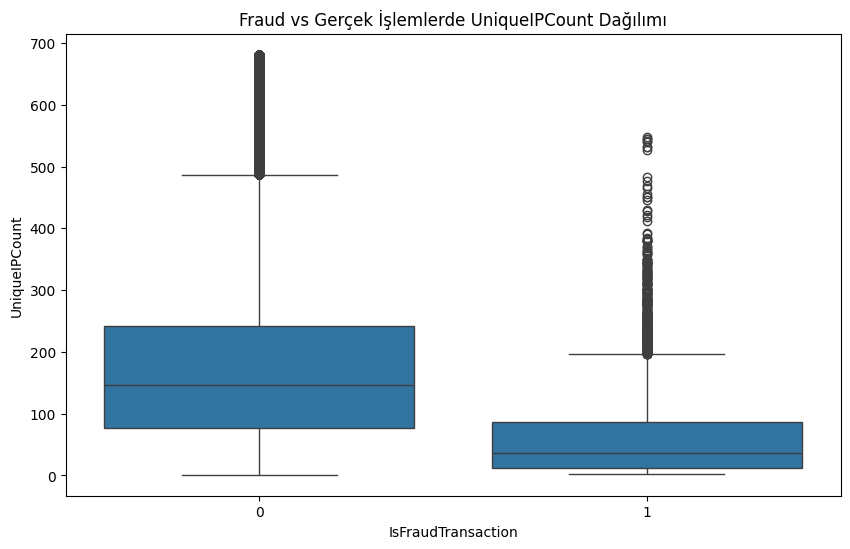

In [ ]:
# IP_Subnet ve UniqueIPCount analizleri

print("--- IP_Subnet Analizi ---")
ip_fraud_analysis = df.groupby('IP_Subnet').agg(
    total_count=('IsFraudTransaction', 'count'),
    fraud_count=('IsFraudTransaction', 'sum')
)
ip_fraud_analysis['fraud_rate'] = ip_fraud_analysis['fraud_count'] / ip_fraud_analysis['total_count']

display(ip_fraud_analysis.sort_values(by='fraud_count', ascending=False).head(15))

print("\n--- UniqueIPCount Dağılım Analizi (Fraud vs Gerçek İşlem) ---")
display(df.groupby('IsFraudTransaction')['UniqueIPCount'].describe())

# Outlier analizi
plt.figure(figsize=(10, 6))
sns.boxplot(x='IsFraudTransaction', y='UniqueIPCount', data=df)
plt.title('Fraud vs Gerçek İşlemlerde UniqueIPCount Dağılımı')
plt.show()

In [ ]:
# IP_Subnet ve UniqueIPCount için risk analizi ve flag ataması yapılır

# Her subnet için fraud oranı hesaplanır
ip_stats = df.groupby('IP_Subnet')['IsFraudTransaction'].agg(['count', 'mean']).reset_index()
ip_stats.columns = ['IP_Subnet', 'Subnet_Transaction_Count', 'Subnet_Fraud_Rate']

# Yüksek riskli subnetler belirlenen mantığa göre tespit edilir: en az 5 işlemde geçen ve fraud oranı > 15%
high_risk_subnets = ip_stats[(ip_stats['Subnet_Fraud_Rate'] > 0.15) & (ip_stats['Subnet_Transaction_Count'] >= 5)]['IP_Subnet'].tolist()

df_encoded['IsHighRiskIPSubnet'] = df['IP_Subnet'].isin(high_risk_subnets).astype(int)

# Outlier analizinde UniqueIPCount'un fraud durumlarında daha düşük olduğu görülür
# 25. percentile altında kalan UniqueIPCount değerleri flag'lenir. Çok fp üretmesinden dolayı iyileştirmeye ihtiyaç duymakta
fraud_q1_ip = df[df['IsFraudTransaction'] == 1]['UniqueIPCount'].quantile(0.25)
df_encoded['IsLowUniqueIPCount'] = (df['UniqueIPCount'] < fraud_q1_ip).astype(int)

print(f"Yüksek riskli IPSubnet sayısı: {len(high_risk_subnets)}")
print("IsHighRiskIPSubnet ve IsLowUniqueIPCount feature'ları df_encoded'a eklendi.")

Yüksek riskli IPSubnet sayısı: 102
IsHighRiskIPSubnet ve IsLowUniqueIPCount feature'ları df_encoded'a eklendi.


Yeni flag feature'ları:


,IsFraudTransaction,IsHighRiskIPSubnet,IsLowUniqueIPCount,IP_Subnet,UniqueIPCount
26,0,1,0,37.154.188,132
57,0,0,1,78.175.52,6
225,0,0,1,178.233.172,11
244,0,0,1,151.135.25,8
247,0,1,0,178.241.75,121



IsHighRiskIPSubnet ile yakalanan fraud işlemi sayısı: 2783

IsHighRiskIPSubnet ile bulunan false positive sayısı: 4436


IsLowUniqueIPCount ile yakalanan fraud işlemi sayısı: 1305

IsLowUniqueIPCount ile bulunan false positive sayısı: 15757


İki flag ile birlikte yakalanan fraud işlemi sayısı: 677

İki flag ile birlikte bulunan false positive sayısı: 72



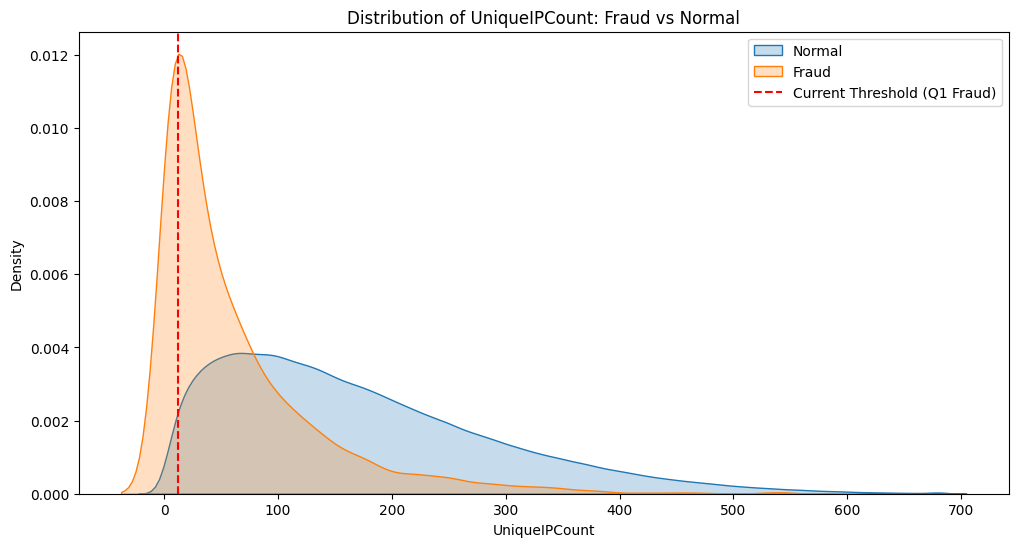

In [ ]:
# Flag sonuçları incelenir.
# İki flag'in birlikte kullanıldığı durumlar çok başarılı çalışsa da az filtreleme yapar.

flagged_inspect = df_encoded[(df_encoded['IsHighRiskIPSubnet'] == 1) | (df_encoded['IsLowUniqueIPCount'] == 1)].head()

print("Yeni flag feature'ları:")
display(flagged_inspect[['IsFraudTransaction', 'IsHighRiskIPSubnet', 'IsLowUniqueIPCount', 'IP_Subnet', 'UniqueIPCount']])

# tp ve fp değerlerine bakılır
overlap_count = df_encoded[(df_encoded['IsHighRiskIPSubnet'] == 1) & (df_encoded['IsFraudTransaction'] == 1)].shape[0]
print(f"\nIsHighRiskIPSubnet ile yakalanan fraud işlemi sayısı: {overlap_count}")
df_fp_subnet = df_encoded[(df_encoded['IsFraudTransaction'] == 0) & (df_encoded['IsHighRiskIPSubnet'] == 1)]
print(f"\nIsHighRiskIPSubnet ile bulunan false positive sayısı: {len(df_fp_subnet)}\n")

overlap_count = df_encoded[(df_encoded['IsLowUniqueIPCount'] == 1) & (df_encoded['IsFraudTransaction'] == 1)].shape[0]
print(f"\nIsLowUniqueIPCount ile yakalanan fraud işlemi sayısı: {overlap_count}")
df_fp_ipcount = df_encoded[(df_encoded['IsFraudTransaction'] == 0) & (df_encoded['IsLowUniqueIPCount'] == 1)]
print(f"\nIsLowUniqueIPCount ile bulunan false positive sayısı: {len(df_fp_ipcount)}\n")

overlap_count = df_encoded[(df_encoded['IsHighRiskIPSubnet'] == 1) & (df_encoded['IsFraudTransaction'] == 1) & (df_encoded['IsLowUniqueIPCount'] == 1)].shape[0]
print(f"\nİki flag ile birlikte yakalanan fraud işlemi sayısı: {overlap_count}")
df_fp_both = df_encoded[(df_encoded['IsFraudTransaction'] == 0) & ((df_encoded['IsHighRiskIPSubnet'] == 1) & (df_encoded['IsLowUniqueIPCount'] == 1))]
print(f"\nİki flag ile birlikte bulunan false positive sayısı: {len(df_fp_both)}\n")

# Fraud olan ve olmayan değerler grafikleştirilir ve 25. percentilin treshold olarak seçilmesi değerlendirilir
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df[df['IsFraudTransaction'] == 0], x='UniqueIPCount', label='Normal', fill=True, common_norm=False)
sns.kdeplot(data=df[df['IsFraudTransaction'] == 1], x='UniqueIPCount', label='Fraud', fill=True, common_norm=False)
plt.title('Distribution of UniqueIPCount: Fraud vs Normal')
plt.axvline(x=df[df['IsFraudTransaction'] == 1]['UniqueIPCount'].quantile(0.25), color='r', linestyle='--', label='Current Threshold (Q1 Fraud)')
plt.legend()
plt.show()

In [ ]:
# IsLowUniqueIPCount için treshold değerleri denenerek çok daha yüksek başarı oranları elde edilebilmekte (TP: 445, FP: 2297)
# Ancak yakalanan fraud durumlarında azalma olduğu için şu anda 25. percentile değeri ile ilerlenilecek
# Feature optimizasyonu gerekirse geri dönülüp değerlendirilecek

results = []
baseline_fraud_rate = df_encoded['IsFraudTransaction'].mean() * 100

# Q1 harici tresholdlar test edilir
for t in range(2, 10, 2):
    subset = df_encoded[df_encoded['UniqueIPCount'] < t]
    tp = subset[subset['IsFraudTransaction'] == 1].shape[0]
    fp = subset[subset['IsFraudTransaction'] == 0].shape[0]
    total = tp + fp

    if total > 0:
        precision = (tp / total) * 100
        enrichment = precision / (baseline_fraud_rate + 1e-9)
        results.append({
            'Threshold <': t,
            'TP (Fraud)': tp,
            'FP (Normal)': fp,
            'Fraud_Prob%': round(precision, 2),
            'Enrichment_Factor': round(enrichment, 1),
            'Flagged_Volume': tp + fp,
            'Flagged_Volume_%_Total': round((tp + fp) / len(df_encoded) * 100, 2)
        })

analysis_df = pd.DataFrame(results)
print(f"Başlangıçta Fraud İhtimali: {round(baseline_fraud_rate, 3)}%")
display(analysis_df)

print("\n**Enrichment_Factor 10'sa, flag'lenen bir girdinin fraud çıkma ihtimali herhangi bir girdinin ihtimalinin 10 katıdır.")

Başlangıçta Fraud İhtimali: 0.628%


,Threshold <,TP (Fraud),FP (Normal),Fraud_Prob%,Enrichment_Factor,Flagged_Volume,Flagged_Volume_%_Total
0,2,0,395,0.00,0.0,395,0.05
1,4,445,2297,16.23,25.8,2742,0.32
2,6,761,4908,13.42,21.4,5669,0.67
3,8,969,8145,10.63,16.9,9114,1.07



**Enrichment_Factor 10'sa, flag'lenen bir girdinin fraud çıkma ihtimali herhangi bir girdinin ihtimalinin 10 katıdır.


  *   Bir cihazdan birden çok hesaba giriş yapılmış mı diye kontrol edilerek `DeviceId` ve `UniqueAccountCount`tan `IsSharedDevice` flag'i türetilir.

In [ ]:
device_sharing = df.groupby('DeviceId')['AccountNumber'].nunique().reset_index()
device_sharing.columns = ['DeviceId', 'UniqueAccountCount']

# Birden fazla hesaba girilen cihazlar flag'lenir
shared_devices = device_sharing[device_sharing['UniqueAccountCount'] > 1]['DeviceId'].tolist()
df_encoded['IsSharedDevice'] = df['DeviceId'].isin(shared_devices).astype(int)

df_encoded = df_encoded.drop(columns=['AccountNumber', 'IP_Subnet', 'UniqueIPCount'])

# Model eğitildiğinde IsSharedDevice ve IsHighRiskIPSubnet arasındaki ilişkiyi bulması beklenir
overlap = df_encoded[(df_encoded['IsSharedDevice'] == 1) & (df_encoded['IsHighRiskIPSubnet'] == 1)]

tp = overlap[overlap['IsFraudTransaction'] == 1].shape[0]
fp = overlap[overlap['IsFraudTransaction'] == 0].shape[0]

print(f"Hem SharedDevice hem HighRiskIPSubnet flag'li işlemlerde örtüşme (overlap):")
print(f"TP: {tp}\nFP: {fp}")
if (tp + fp) > 0:
    print(f"Precision: {round(tp/(tp+fp)*100, 2)}%")

Hem SharedDevice hem HighRiskIPSubnet flag'li işlemlerde örtüşme (overlap):
TP: 2742
FP: 4436
Precision: 38.2%


## D. Outlier Analizi & Scaling & Covariance

  *   `CustomerTenure` ve `TransactionAmount` kolonlarında scaling öncesi outlier analizi yapabilmek için *Interquartile Range (IQR)* metodu kullanılır.

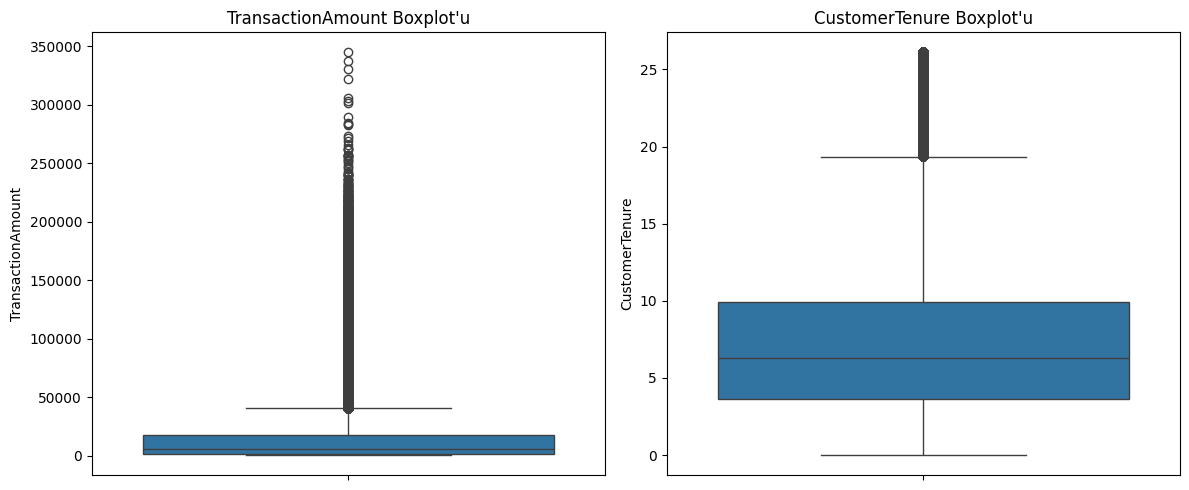

--- TransactionAmount ---
TransactionAmount - Lower Bound: -22203.84, Upper Bound: 40818.44
Toplam TransactionAmount Outlier Sayısı: 70956 (8.35%)
Mantıklı Aralık: 0 - 40818.44
Outlier'lardaki Fraud Oranı: 1.17%
Global Fraud Oranı: 0.63%

--- CustomerTenure ---
CustomerTenure - Lower Bound: -5.85, Upper Bound: 19.35
Toplam CustomerTenure Outlier Sayısı: 22598 (2.66%)
Mantıklı Aralık: 0 - 19.35
Outlier'lardaki Fraud Oranı: 1.25%
Global Fraud Oranı: 0.63%



In [ ]:
# Outlier analizi yapılacak nümerik kolonlar
num_cols = ['TransactionAmount', 'CustomerTenure']

plt.figure(figsize=(12, 5))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'{col} Boxplot\'u')

plt.tight_layout()
plt.show()

# IQR ve outlier sayıları hesaplanır
for col in num_cols:
    IQR = df[col].quantile(0.75) - df[col].quantile(0.25)
    upper_bound = df[col].quantile(0.75) + 1.5 * IQR
    lower_bound = df[col].quantile(0.25) - 1.5 * IQR

    # CustomerTenure ve TransactionAmount negatif olamayacağı için negatif değer var mı diye kontrol edilir
    # Aralık 0 - upper_bound olarak belirlenir. upper_bound üstündeki veriler outlier'dır
    # Silme ihtimaline karşı outlier'ların içinde ne kadar fraud verisi bulunuyor tespit edilir
    high_outliers = df[df[col] > upper_bound]
    fraud_in_outliers = high_outliers['IsFraudTransaction'].mean() * 100

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f'--- {col} ---')
    print(f"{col} - Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"Toplam {col} Outlier Sayısı: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    print(f'Mantıklı Aralık: 0 - {upper_bound:.2f}')
    print(f'Outlier\'lardaki Fraud Oranı: {fraud_in_outliers:.2f}%')
    print(f'Global Fraud Oranı: {df["IsFraudTransaction"].mean()*100:.2f}%\n')

  *   Outlier'lardeki fraud oranının globale oranla yaklaşık 2 kat fazla olduğu görülür. Bu durum yüksek miktarlı işlemlerin ve uzun süreli müşterilerin fraud işlemi belirtmesinin daha muhtemel olduğunu gösterir. Bu nedenle outlier'lar temizlenmez, scaling bu durum göz önünde bulundurularak yapılır.
      *   Scaling için outlier verileri tutularak değerler ölçeklendirileceğinden *RobustScaler* tercih edilir. Medyan ve IQR kullanan *RobustScaler*, outlier'lardan *StandardScaler* kadar etkilenmez.

Robust Scaling uygulandı.


,TransactionAmount,CustomerTenure
count,849376.000000,849376.000000
mean,0.499986,0.160373
std,1.254610,0.778240
min,-0.323610,-1.000000
25%,-0.264614,-0.428571
50%,0.000000,0.000000
75%,0.735386,0.571429
max,21.514637,3.142857


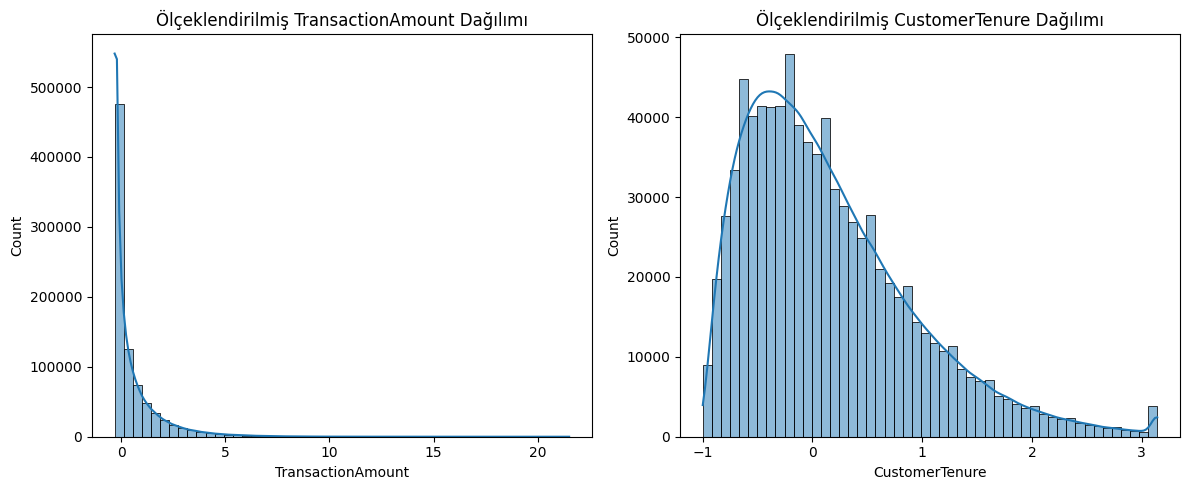

In [ ]:
# Scaling

# Outlier analizinde outlier'ların fraud tespitinde etkili olduğu görülür
# Bu veriler tutularak ölçeklendirileceğinden RobustScaler tercih edilir
# Medyan ve IQR kullanan RobustScaler, outlier'lardan StandardScaler kadar etkilenmez
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()

scale_cols = ['TransactionAmount', 'CustomerTenure']
df_encoded[scale_cols] = robust_scaler.fit_transform(df_encoded[scale_cols])

print("Robust Scaling uygulandı.")
display(df_encoded[scale_cols].describe())

plt.figure(figsize=(12, 5))
for i, col in enumerate(scale_cols, 1):
    plt.subplot(1, 2, i)
    sns.histplot(df_encoded[col], bins=50, kde=True)
    plt.title(f'Ölçeklendirilmiş {col} Dağılımı')
plt.tight_layout()
plt.show()

  *   Üretilen feature'ların covariance'ları kontrol edilir. Yüksek korelasyonlu feature'ların (r > 0.9) model başarısını etkilememesi için lineer ilişkili feature'lardan biri atılabilir.

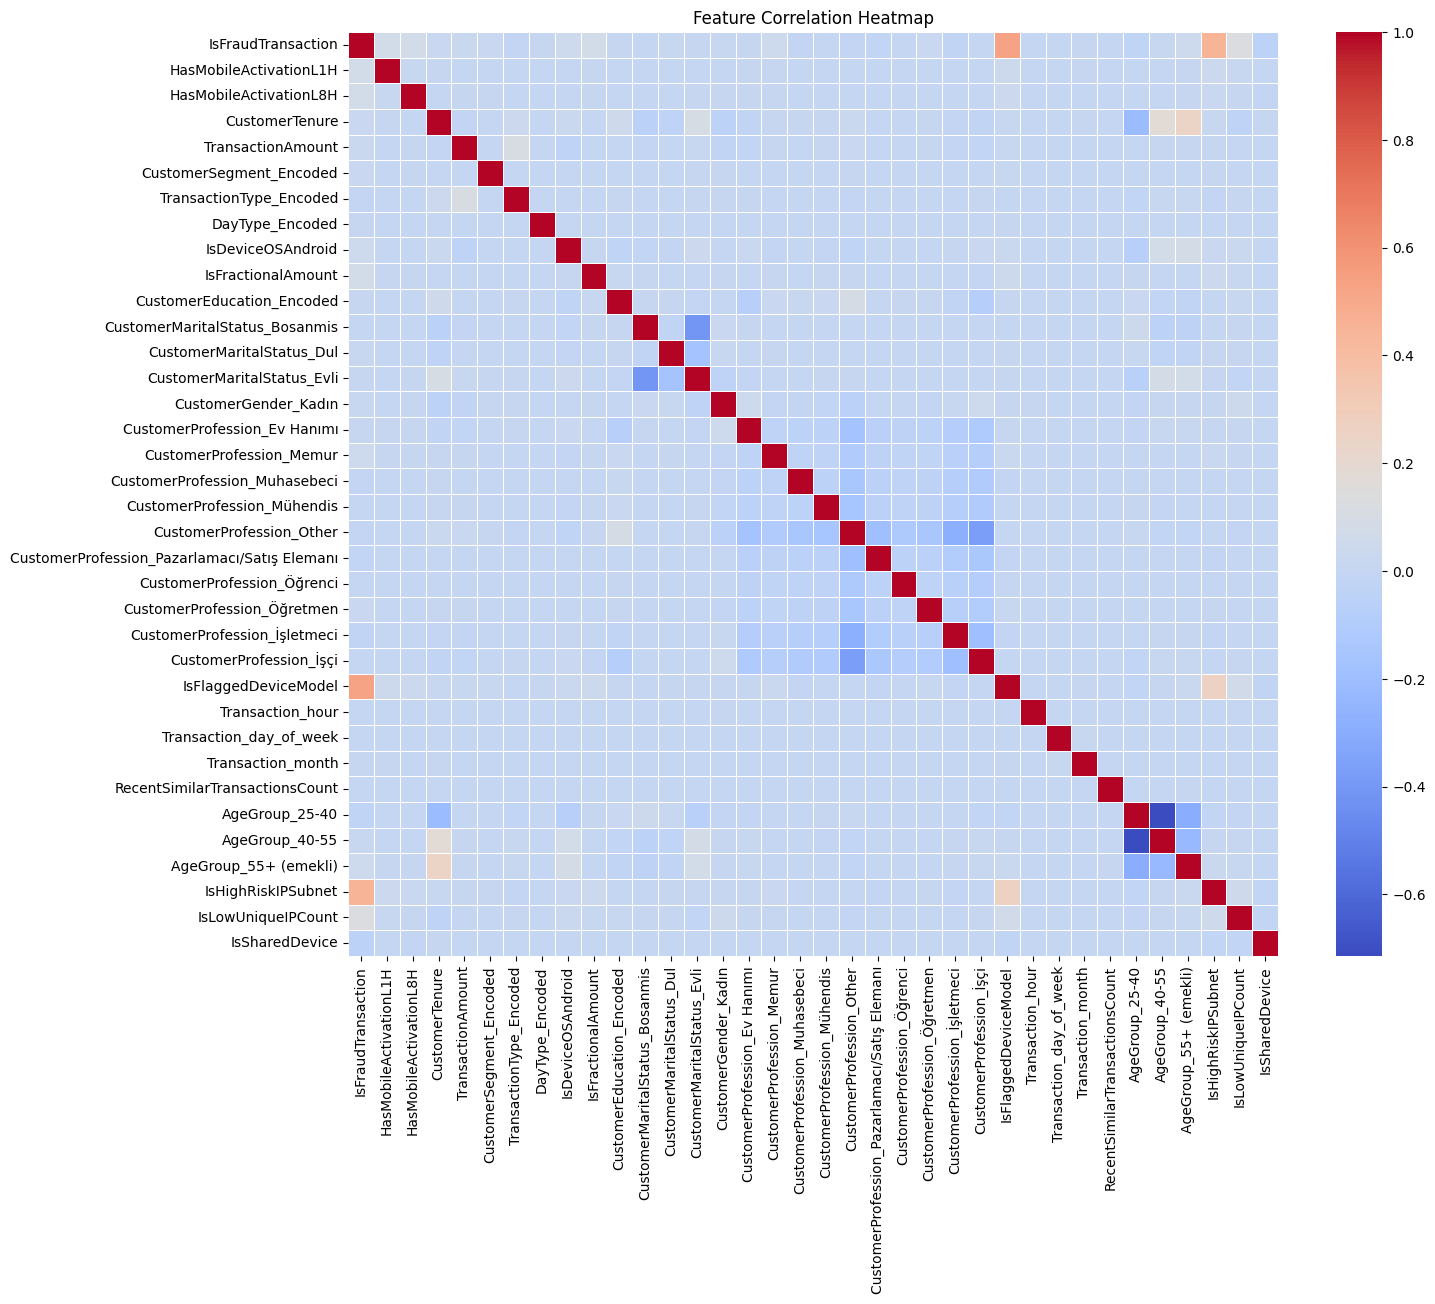

90% üzerinde korelasyonu olan kolon çifti bulunamadı.


In [ ]:
# Correlation matrix hesaplama

plt.figure(figsize=(15, 12))
correlation_matrix = df_encoded.select_dtypes(include=[np.number]).corr()

# Heatmap
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# Korelasyonu yüksek kolon çiftleri bulunur
upper = correlation_matrix.abs().where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# Yüksek korelasyonlu feature'ların (> 0.9) model başarısını etkilememesi için lineer ilişkili feature'lardan biri atılabilir
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

if to_drop:
    print(f"Lineer ilişkili/Yüksek korelasyonlu kolonlar (>0.9): {to_drop}")
else:
    print("90% üzerinde korelasyonu olan kolon çifti bulunamadı.")

Temizlenen veriden ilk feature'lar seçilir ve model eğitimine geçilir. Eğer sonuçlar istendiği şekilde olmazsa ileride feature seçimi değiştirilebilir.

# 2) Model Eğitimi ve Performans Ölçümü

**A. Logistic Regression**

**B. Random Forest**

**C. XGBoost**

**D. Balanced Random Forest**

**D. Ensemble Learning**

**F. Feature Seçimi**

**G. Performans İyileştirme Çabaları**

## A. Logistic Regression

*   Imbalanced bir veri seti ile (5338/849563) çalışıldığından veri rastgele değil Stratified olarak bölünür. Fraud verisi train ve test dataset'lerinde aynı oranda bulunur.



In [ ]:
from sklearn.model_selection import train_test_split

# XGBoost'a göre en önemsiz 10 kolon feature'lardan çıkartılarak performans incelenir
least_important_col = ['IsFraudTransaction', 'RecentSimilarTransactionsCount', 'CustomerProfession_İşçi', 'CustomerMaritalStatus_Bosanmis', 'CustomerProfession_Muhasebeci', 'CustomerProfession_Other'] #, 'CustomerEducation_Encoded', 'Transaction_month', 'Transaction_day_of_week', 'CustomerProfession_Ev Hanımı', 'DayType_Encoded']

#X = df_encoded.drop(columns=least_important_col) # features

X = df_encoded.drop(columns='IsFraudTransaction')

# Tüm feature'lar yerine XGBoost'un en çok faydalandığı feature'lar seçilir ve performans incelenir
y = df_encoded['IsFraudTransaction']  #target

# Stratified Split
# train (80%), test (20%)
# 'stratify=y' kullanarak fraud oranının her iki sette de aynı kalması sağlanır (imbalanced)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")

print(f"\nTrain Seti Fraud Oranı: %{y_train.mean()*100:.3f}")
print(f"Test Seti Fraud Oranı: %{y_test.mean()*100:.3f}")

NameError: name 'df_encoded' is not defined

In [ ]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# class_weight='balanced' ile fraud işlemlerine daha fazla önem verilir
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("--- Logistic Regression Sonuçları ---\n")
print(classification_report(y_test, y_pred_lr))
print(f"ROC AUC Skoru: {roc_auc_score(y_test, y_proba_lr):.4f}")

## B. Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# n_estimators=100: 100 adet decision tree kullanılacak
# class_weight='balanced' (çünkü dataset imbalanced)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("--- Random Forest Sonuçları ---\n")
print(classification_report(y_test, y_pred_rf))
print(f"ROC AUC Skoru: {roc_auc_score(y_test, y_proba_rf):.4f}")

--- Random Forest Sonuçları ---

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    168808
           1       0.91      0.47      0.62      1068

    accuracy                           1.00    169876
   macro avg       0.95      0.73      0.81    169876
weighted avg       1.00      1.00      1.00    169876

ROC AUC Skoru: 0.9171


## C. XGBoost

In [ ]:
from xgboost import XGBClassifier

# Scale weight hesaplanması 0 (çoğunluk) / 1 (azınlık)
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(eval_metric='logloss', scale_pos_weight=scale_weight, random_state=42)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("--- XGBoost Sonuçları ---\n")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC AUC Skoru: {roc_auc_score(y_test, y_proba_xgb):.4f}")

--- XGBoost Sonuçları ---

              precision    recall  f1-score   support

           0       1.00      0.97      0.98    168808
           1       0.13      0.80      0.23      1068

    accuracy                           0.97    169876
   macro avg       0.57      0.88      0.61    169876
weighted avg       0.99      0.97      0.98    169876

ROC AUC Skoru: 0.9529


## D. Balanced Random Forest

*   Imbalanced veri setleri için geliştirilmiş Balanced Random Forest denenir. Fraud durumu için daha doğru sonuçlar verse de RF'ın Voting Classifier'ı dengelemesi nedeniyle bu yöntemle devam edilmez.




In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier

# sampling_strategy='auto' her tree'ye balanced bir alt küme verir
brf_model = BalancedRandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, sampling_strategy='auto')

print("Training BalancedRandomForestClassifier...")
brf_model.fit(X_train, y_train)

y_pred_brf = brf_model.predict(X_test)
y_proba_brf = brf_model.predict_proba(X_test)[:, 1]

print("--- Balanced Random Forest Sonuçları ---\n")
print(classification_report(y_test, y_pred_brf))
print(f"ROC AUC Skoru: {roc_auc_score(y_test, y_proba_brf):.4f}")

Training BalancedRandomForestClassifier...
--- Balanced Random Forest Sonuçları ---

              precision    recall  f1-score   support

           0       1.00      0.93      0.96    168808
           1       0.07      0.87      0.13      1068

    accuracy                           0.93    169876
   macro avg       0.54      0.90      0.55    169876
weighted avg       0.99      0.93      0.96    169876

ROC AUC Skoru: 0.9588


## E. Ensemble Learning

LR ve XGB sonuçları yüksek recall düşük precision, RF sonuçları da tam tersini gösterir. Bu sonuçları birleştiren bir yöntem denenerek ortalama sonuç incelenir. (Bu kısım diğer iyileştirme denemelerinden sonra eklenmiştir)

*   Daha önce eğitilip performansı ölçülen modeller (LR + RF + XGB) Soft Voting ensemble ile bir araya getirilir. Precision ve F1 Score oldukça iyileşir. Recall'da da ciddi düşüş görülmez. Bu yöntemin kullanılmasına karar verilir.
    *   Robustness analizi için seçilen model üzerinde StratifiedKFold uygulanır.

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import pandas as pd

# Daha önce eğitilip performansı ölçülen modeller (LR + RF + XGB) Soft Voting ensemble ile bir araya getirilir.
# Soft voting ihtimallerin ortalamasını alır, imbalanced veri setlerinde genellikle tercih edilir
voting_clf = VotingClassifier(
    estimators=[
        ('lr', log_reg),
        ('rf', rf_model), #bbc_rf_model ile de denendi ancak rf sonuçları iyileştiğinden ortalama başarı düştü
        ('xgb', xgb_model)
    ],
    voting='soft',
    n_jobs=-1
)

print("Training Voting Classifier Ensemble...")
voting_clf.fit(X_train, y_train)

y_pred_vote = voting_clf.predict(X_test)
y_proba_vote = voting_clf.predict_proba(X_test)[:, 1]

print("--- Voting Classifier (LR + RF + XGB) Sonuçları ---\n")
print(classification_report(y_test, y_pred_vote))
print(f"ROC AUC Skoru: {roc_auc_score(y_test, y_proba_vote):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_vote)
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix:\nTN: {tn} | FP: {fp}\nFN: {fn} | TP: {tp}")

Training Voting Classifier Ensemble...
--- Voting Classifier (LR + RF + XGB) Sonuçları ---

              precision    recall  f1-score   support

           0       1.00      0.99      0.99    168808
           1       0.31      0.75      0.44      1068

    accuracy                           0.99    169876
   macro avg       0.66      0.87      0.72    169876
weighted avg       0.99      0.99      0.99    169876

ROC AUC Skoru: 0.9642

Confusion Matrix:
TN: 167060 | FP: 1748
FN: 272 | TP: 796


In [ ]:
# Voting Classifier + StratifiedKFold

# Önceden tanımlanan stratified fold'lar kullanılır
scoring = ['recall', 'precision', 'roc_auc']

print("Voting Classifier için Stratified 5-Fold Cross-Validation başlatılıyor...")
voting_cv_results = cross_validate(
    voting_clf, X, y, cv=skf, scoring=scoring, n_jobs=-1
)

print("--- Voting Classifier Cross-Validation Sonuçları ---")
print(f"Average Recall:    {voting_cv_results['test_recall'].mean():.4f} (+/- {voting_cv_results['test_recall'].std():.4f})")
print(f"Average Precision: {voting_cv_results['test_precision'].mean():.4f} (+/- {voting_cv_results['test_precision'].std():.4f})")
print(f"Average ROC AUC:   {voting_cv_results['test_roc_auc'].mean():.4f} (+/- {voting_cv_results['test_roc_auc'].std():.4f})")

voting_cv_df = pd.DataFrame(voting_cv_results)
display(voting_cv_df[['test_recall', 'test_precision', 'test_roc_auc']])

Voting Classifier için Stratified 5-Fold Cross-Validation başlatılıyor...
--- Voting Classifier Cross-Validation Sonuçları ---
Average Recall:    0.7394 (+/- 0.0154)
Average Precision: 0.3030 (+/- 0.0079)
Average ROC AUC:   0.9566 (+/- 0.0041)


,test_recall,test_precision,test_roc_auc
0,0.714419,0.288796,0.950020
1,0.731022,0.306483,0.953546
2,0.756326,0.312186,0.960104
3,0.741573,0.306502,0.959600
4,0.753745,0.300822,0.959739


## F. Feature Seçimi

  *   Tüm feature'lar kullanılarak elde edilen ilk performansı iyileştirmek için *Feature Importance, L1 Regularization (Lasso), Recursive Feature Elimination* iyileştirmeleri denenir.

*   Tree tabanlı (Random Forest, XGBoost) modellerde **Feature Importance** bakılarak sonucu en çok etkileyen/etkilemeyen feature'lar bulunur. Deneysel olarak en önemsiz N feature eksiltilerek performans ölçülür.
    *  Feature'lar kendi başlarına önemli olmasalar da ilişkisel olarak kullanılabildiklerinden sonuçlarda büyük bir değişiklik olmamış, yer yer düşüşler gerçekleşmiştir. Bu yaklaşımdan vazgeçilmiştir.


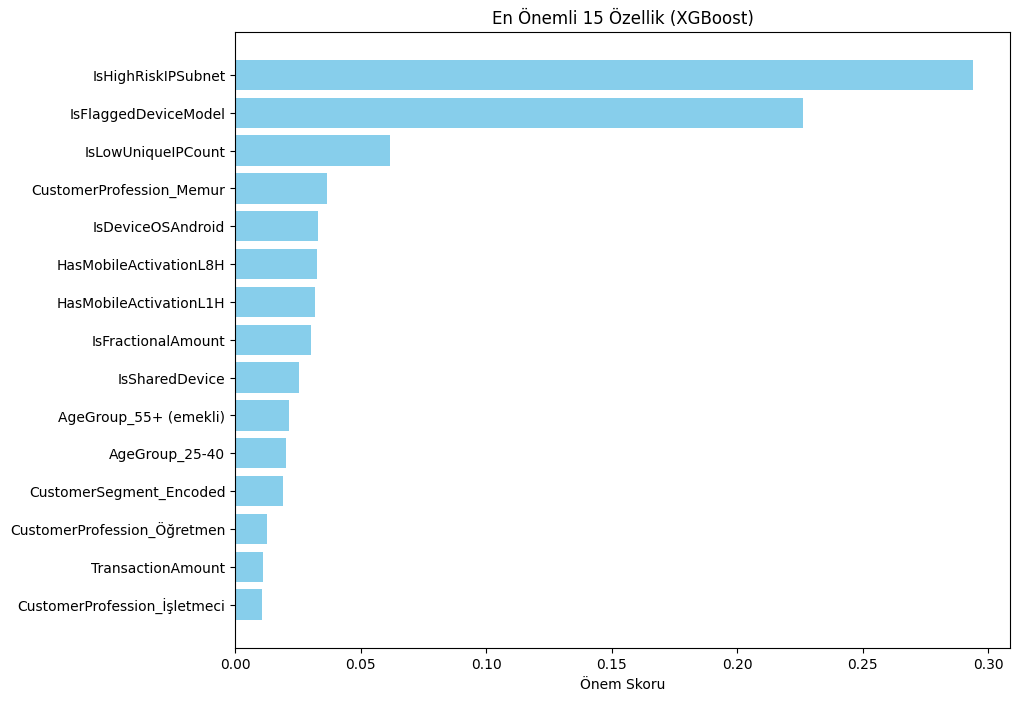

,Feature,Importance
11,CustomerMaritalStatus_Dul,0.007209
12,CustomerMaritalStatus_Evli,0.006921
25,Transaction_hour,0.006896
20,CustomerProfession_Öğrenci,0.006802
2,CustomerTenure,0.006731
6,DayType_Encoded,0.006670
14,CustomerProfession_Ev Hanımı,0.006580
26,Transaction_day_of_week,0.006485
27,Transaction_month,0.006477
9,CustomerEducation_Encoded,0.006095


In [ ]:
# Feature Importance

# Elde edilen performansı iyileştirmek için feature önemi belirlenir ve modele verilecek feature'lar seçilir

import matplotlib.pyplot as plt
import pandas as pd

# XGBoost modelinden alınır
importances = xgb_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'].head(15), feature_importance_df['Importance'].head(15), color='skyblue')
plt.xlabel('Önem Skoru')
plt.title('En Önemli 15 Feature (XGBoost)')
plt.gca().invert_yaxis()
plt.show()

# Droplanabilecek feature'lar
display(feature_importance_df.tail(15))

*   Logistic Regression için **L1 cezalandırması** ile ceza uygulayarak önemsiz özellik katsayısı düşürülür.
    *  Farklı ceza katsayıları (c) ile denenmiştir. c = 0.01 için 6 feature elimine edilmiştir ve sonuç çok az iyileşmiştir. Ancak LogReg precision'ı başlangıça çok düşük olduğu için bu iyileştirme yeterli olmamıştır.

In [ ]:
#L1 Regularization (Lasso) ile ceza uygulayarak önemsiz özellik katsayısı düşürülür

# C değerini küçülterek ceza artırılır:
# C = 0.1 için 0 feature (performansa etkisi yok),
# C = 0.001 için 6 feature (performans çok çok az arttı),
# C = 0.0001 için 16 feature silindi (performans düştü)
log_reg_l1 = LogisticRegression(penalty='l1', C=0.01, solver='liblinear',
                                class_weight='balanced', random_state=42)

log_reg_l1.fit(X_train, y_train)

coefficients = log_reg_l1.coef_[0]
zero_cols = X.columns[coefficients == 0]
non_zero_cols = X.columns[coefficients != 0]

print(f"Toplam Feature Sayısı: {len(X.columns)}")
print(f"L1 (Lasso) tarafından sıfıra indirilen özellik sayısı: {len(zero_cols)}")
print(f"Modelde kalan feature sayısı: {len(non_zero_cols)}")

if len(non_zero_cols) > 0:
    print(f"\nKalan Önemli Feature'lar: {list(non_zero_cols)}")

Toplam Feature Sayısı: 35
L1 (Lasso) tarafından sıfıra indirilen özellik sayısı: 2
Modelde kalan feature sayısı: 33

Kalan Önemli Feature'lar: ['HasMobileActivationL1H', 'HasMobileActivationL8H', 'CustomerTenure', 'TransactionAmount', 'CustomerSegment_Encoded', 'TransactionType_Encoded', 'DayType_Encoded', 'IsDeviceOSAndroid', 'IsFractionalAmount', 'CustomerEducation_Encoded', 'CustomerMaritalStatus_Dul', 'CustomerMaritalStatus_Evli', 'CustomerGender_Kadın', 'CustomerProfession_Ev Hanımı', 'CustomerProfession_Memur', 'CustomerProfession_Muhasebeci', 'CustomerProfession_Mühendis', 'CustomerProfession_Other', 'CustomerProfession_Pazarlamacı/Satış Elemanı', 'CustomerProfession_Öğrenci', 'CustomerProfession_Öğretmen', 'CustomerProfession_İşletmeci', 'CustomerProfession_İşçi', 'IsFlaggedDeviceModel', 'Transaction_hour', 'Transaction_day_of_week', 'Transaction_month', 'AgeGroup_25-40', 'AgeGroup_40-55', 'AgeGroup_55+ (emekli)', 'IsHighRiskIPSubnet', 'IsLowUniqueIPCount', 'IsSharedDevice']


*   Logistic Regression için **Recursive Feature Elimination** denenir ve optimal feature sayısı 33 bulunur. `Transaction_day_of_week` ve `Transaction_month` elenir.
     *  Önerilen feature seçimi uygulandığında sonuçlarda iyileşme görülmemiştir.

In [ ]:
from sklearn.feature_selection import RFECV

# Recursive Feature Elimination + Logistic Regression
estimator = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# RFECV cross-validation'a göre optimum feature sayısını verir
# step=1 her seferinde 1 feature silinir
selector = RFECV(estimator, step=1, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

print("RFE süreci başlatılıyor (bu işlem birkaç dakika sürebilir)...")
selector = selector.fit(X_train, y_train)

print(f"\nOptimal özellik sayısı: {selector.n_features_}")

selected_features = X.columns[selector.support_].tolist()
print(f"Seçilen Özellikler: {selected_features}")

RFE süreci başlatılıyor (bu işlem birkaç dakika sürebilir)...
Fitting estimator with 35 features.
Fitting estimator with 34 features.

Optimal özellik sayısı: 33
Seçilen Özellikler: ['HasMobileActivationL1H', 'HasMobileActivationL8H', 'CustomerTenure', 'TransactionAmount', 'CustomerSegment_Encoded', 'TransactionType_Encoded', 'DayType_Encoded', 'IsDeviceOSAndroid', 'IsFractionalAmount', 'CustomerEducation_Encoded', 'CustomerMaritalStatus_Bosanmis', 'CustomerMaritalStatus_Dul', 'CustomerMaritalStatus_Evli', 'CustomerGender_Kadın', 'CustomerProfession_Ev Hanımı', 'CustomerProfession_Memur', 'CustomerProfession_Muhasebeci', 'CustomerProfession_Mühendis', 'CustomerProfession_Other', 'CustomerProfession_Pazarlamacı/Satış Elemanı', 'CustomerProfession_Öğrenci', 'CustomerProfession_Öğretmen', 'CustomerProfession_İşletmeci', 'CustomerProfession_İşçi', 'IsFlaggedDeviceModel', 'Transaction_month', 'RecentSimilarTransactionsCount', 'AgeGroup_25-40', 'AgeGroup_40-55', 'AgeGroup_55+ (emekli)', 'IsH

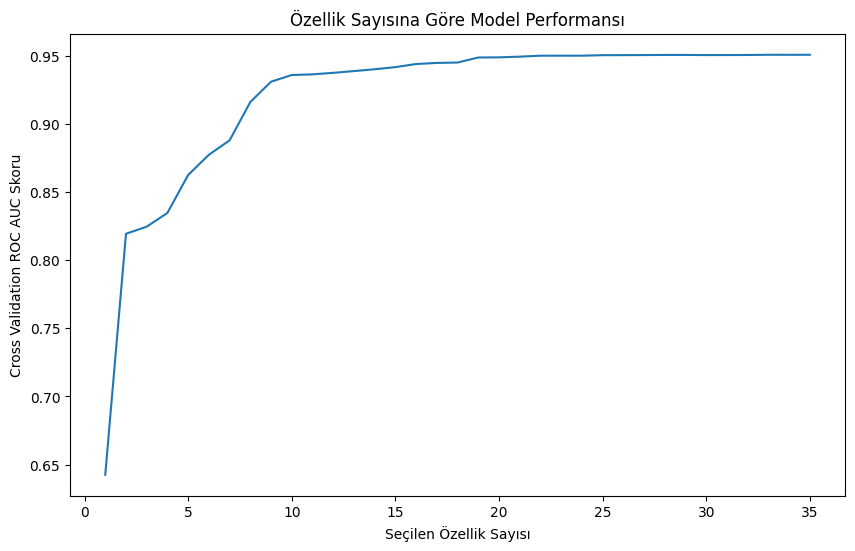

--- RFE Sonrası Logistic Regression Sonuçları ---

              precision    recall  f1-score   support

           0       1.00      0.94      0.97    168808
           1       0.08      0.85      0.15      1068

    accuracy                           0.94    169876
   macro avg       0.54      0.90      0.56    169876
weighted avg       0.99      0.94      0.96    169876

ROC AUC Skoru: 0.9591


In [ ]:
# RFE Performans Grafiği
plt.figure(figsize=(10, 6))
plt.xlabel("Seçilen Özellik Sayısı")
plt.ylabel("Cross Validation ROC AUC Skoru")
plt.plot(range(1, len(selector.cv_results_['mean_test_score']) + 1), selector.cv_results_['mean_test_score'])
plt.title("Özellik Sayısına Göre Model Performansı")
plt.show()

# RFE uygulanmış model performansı testi
X_train_rfe = selector.transform(X_train)
X_test_rfe = selector.transform(X_test)

final_model_rfe = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
final_model_rfe.fit(X_train_rfe, y_train)

y_pred_rfe = final_model_rfe.predict(X_test_rfe)
y_proba_rfe = final_model_rfe.predict_proba(X_test_rfe)[:, 1]

print("--- RFE Sonrası Logistic Regression Sonuçları ---\n")
print(classification_report(y_test, y_pred_rfe))
print(f"ROC AUC Skoru: {roc_auc_score(y_test, y_proba_rfe):.4f}")

## G. Performans İyileştirme Çabaları


*   **StratifiedKFold**: KFold Cross-Validation'da veri k alt kümeye bölünür. Bu kümeler arasında gezerek variance düşürülür. StratifiedKFold ile bölünmeler stratified (azınlık veri için dengeli) bölünür.
    *   StratifiedKFold direkt olarak sonuçlarda iyileştirme sağlamasa da şimdiye kadar elde edilen sonuçların daha güvenilir (robust) olduğunu doğrular. Variance'ı düşürerek stabilite sağlar. Feature seçimini de daha stabil hale getirir. Bir kümede (fold) iyi çalışmayan bir feature başka birinde iyi sonuçlar verebilir.

In [ ]:
# XGBoost + StratifiedKFold
from sklearn.model_selection import StratifiedKFold, cross_validate

# StratifiedKFold
# n_splits=5: Veriyi 5 kata böler, her kat orijinal fraud oranını korur
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. XGBoost ile Cross-Validation
scoring = ['recall', 'precision', 'roc_auc']

cv_results = cross_validate(
    xgb_model, X, y, cv=skf, scoring=scoring, n_jobs=-1
)

print("--- Stratified 5-Fold Cross-Validation Sonuçları ---")
print(f"Average Recall:    {cv_results['test_recall'].mean():.4f} (+/- {cv_results['test_recall'].std():.4f})")
print(f"Average Precision: {cv_results['test_precision'].mean():.4f} (+/- {cv_results['test_precision'].std():.4f})")
print(f"Average ROC AUC:   {cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std():.4f})")

# Katlama detaylarını görüntüle
import pandas as pd
cv_df = pd.DataFrame(cv_results)
display(cv_df[['test_recall', 'test_precision', 'test_roc_auc']])

--- Stratified 5-Fold Cross-Validation Sonuçları ---
Average Recall:    0.7812 (+/- 0.0162)
Average Precision: 0.1300 (+/- 0.0017)
Average ROC AUC:   0.9451 (+/- 0.0046)


,test_recall,test_precision,test_roc_auc
0,0.750936,0.129417,0.938524
1,0.780694,0.130687,0.943209
2,0.797563,0.132741,0.946686
3,0.784644,0.129601,0.944759
4,0.792135,0.127698,0.952468


*   **Balanced Bagging Classifier**: Farklı alt kümelerde çoklu classifier'ları train edip sonuçları ortalar. Çoğunluk sınıfı under-sampling ile azınlık sınıfa dengeler, bias'ı düşürür, azınlık sınıfın performansını iyileştirir.
    *   XGBoost ile denendiğinde Balanced Bagging Classifier çoğunluk sınıfından under-sampling yaptığı için recall çok hassaslaşır çünkü fraud pattern'larına daha duyarlıdır. Ancak bu FP'i çok arttırdığından precision çok düşer.
    *   Bu nedenle daha iyi sonuçlar alma beklentisiyle yöntem precision'ı daha yüksek, recall'u daha düşük olan Random Forest ile de denenir. Beklendiği gibi Random Forest sonuçları daha dengeli hale gelir. Ancak bu iyileştirme ile bile XGBoost sonuçları daha avantajlıdır.

In [ ]:
from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.metrics import classification_report, roc_auc_score

# BalancedBaggingClassifier + XGBoost
# sampling_strategy='auto' çoğunluk sınıfı azınlık sınıfa eşleşmesi için under-sample'lar
bbc_model = BalancedBaggingClassifier(estimator=xgb_model,
                                      sampling_strategy='auto',
                                      replacement=False,
                                      random_state=42,
                                      n_jobs=-1)

print("Training BalancedBaggingClassifier (XGBoost base)...")
bbc_model.fit(X_train, y_train)

y_pred_bbc = bbc_model.predict(X_test)
y_proba_bbc = bbc_model.predict_proba(X_test)[:, 1]

print("--- Balanced Bagging Classifier (XGBoost) Sonuçları ---\n")
print(classification_report(y_test, y_pred_bbc))
print(f"ROC AUC Skoru: {roc_auc_score(y_test, y_proba_bbc):.4f}")

Training BalancedBaggingClassifier (XGBoost base)...
--- Balanced Bagging Classifier (XGBoost) Sonuçları ---

              precision    recall  f1-score   support

           0       1.00      0.62      0.77    168808
           1       0.02      0.97      0.03      1068

    accuracy                           0.62    169876
   macro avg       0.51      0.79      0.40    169876
weighted avg       0.99      0.62      0.76    169876

ROC AUC Skoru: 0.9544


In [ ]:
# BalancedBaggingClassifier + Random Forest
bbc_rf_model = BalancedBaggingClassifier(estimator=rf_model,
                                         sampling_strategy='auto',
                                         replacement=False,
                                         random_state=42,
                                         n_jobs=-1)

print("Training BalancedBaggingClassifier (Random Forest base)...")
bbc_rf_model.fit(X_train, y_train)

y_pred_bbc_rf = bbc_rf_model.predict(X_test)
y_proba_bbc_rf = bbc_rf_model.predict_proba(X_test)[:, 1]

print("--- Balanced Bagging Classifier (Random Forest) Sonuçları ---\n")
print(classification_report(y_test, y_pred_bbc_rf))
print(f"ROC AUC Skoru: {roc_auc_score(y_test, y_proba_bbc_rf):.4f}")

Training BalancedBaggingClassifier (Random Forest base)...
--- Balanced Bagging Classifier (Random Forest) Sonuçları ---

              precision    recall  f1-score   support

           0       1.00      0.96      0.98    168808
           1       0.11      0.85      0.19      1068

    accuracy                           0.95    169876
   macro avg       0.55      0.90      0.58    169876
weighted avg       0.99      0.95      0.97    169876

ROC AUC Skoru: 0.9615


# 3) Model/Performans Değerlendirmesi


Fraud tespiti, gerçek hayatta da imbalanced veri setleri ile yapıldığı için metriklerin anlamlandırılması ve öncelenmesi oldukça önemlidir.

Yapılan model tercihlerinde ve iyileştirmelerde öncelikle **Recall (Duyarlılık)** değerlendirilmiştir. Fraud işlemlerin çoğunluğunun yakalanması bankanın yaşayacağı maddi kayıpların ve legal sorunların önüne geçer.

Sonrasında **Precision (Kesinlik)** dikkate alınır. False Positive'lerin yüksek olması (precision'ın düşük olması) fraud olmayan işlemler için yanlış alarm oluşturur. Müşterilerin işlemleri incelemeye alınabileceğinden/bloke edilebileceğinden kullanıcı deneyimi olumsuz etkilenir.

Bu iki değerin harmonik ortalaması için **F-1 Score**'a bakılır.

Modelin sınıfları birbirinden ayırma becerisi de **ROC AUC** ile ölçülür.

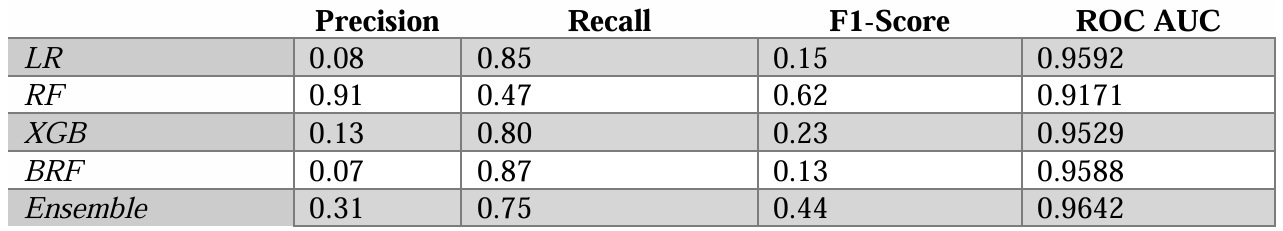
Tablo 1: Denenen modellerin performans karşılaştırması

**RF**, F1-Score bakımından en başarılı modeldir. Precision'ı oldukça yüksek, Recall'u da diğer modellerin Precision oranlarına göre daha iyidir. Ancak fraud tespitinde işlem kaçırmanın maliyeti çok yüksek olabileceğinden Recall değerinin yüksek olması öncelenir.

**LR** ve **XGB** için Recall değerleri istenen şekilde yüksektir. Ancak Precision değerleri oldukça düşüktür. Bu FP ve yanlış alarmları arttıracağından bunların iyileştirilmesi için çeşitli yöntemler denenmiştir.

Sonradan imbalanced veri setleri için geliştirilmiş **Balanced Random Forest** da denenmiştir ancak RF'ın Voting Classifier'ı dengeleyerek daha yüksek başarı sağlamasından dolayı kullanılmamıştır.

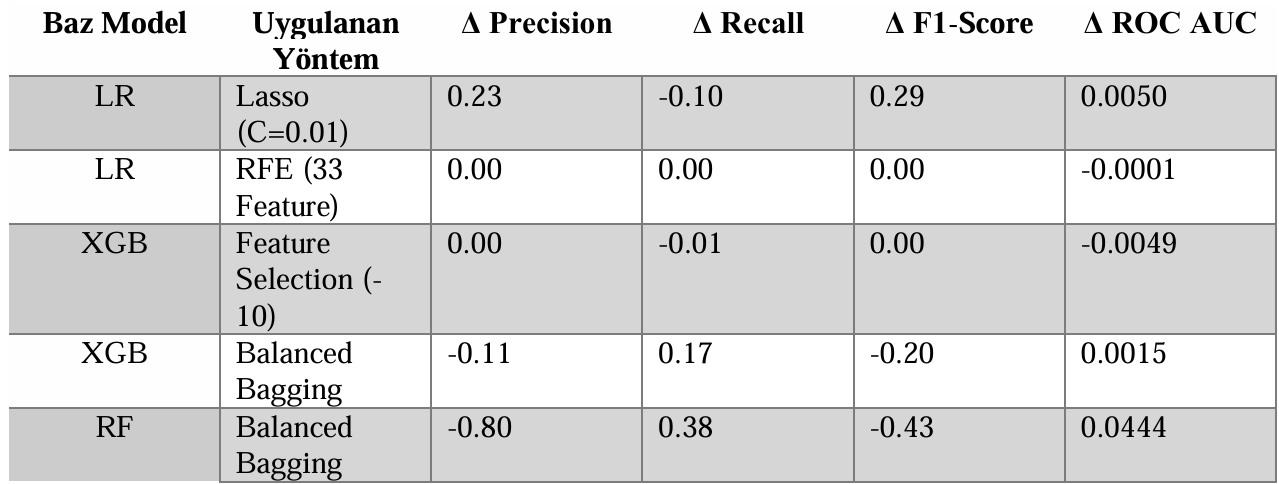
Tablo 2: Feature seçimi ve iyileştirme denemelerinin performansa etkisi

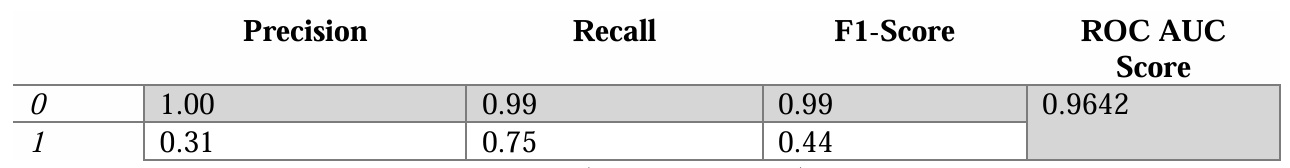
Tablo 3: Seçilen modelin (Ensemble Learning) performansı

Sonuçların iyileştirilmesi adına LR için L1 Regularization (Lasso), Recursive Feature Elimination; RF için Balanced Bagging Classifier; XGB için Feature Importance, StratifiedKFold, Balanced Bagging Classifier denenmiştir. RF için Balanced Bagging Classifier başarılı olmuş ve Recall seviyesi iyileştirilmiştir ancak XGB'nin altında kalmıştır.

3 modelin farklı Precision ve Recall sonuçları vermesi nedeniyle bu yöntemleri birleştirecek bir yöntem araştırılmış, bu modellere Ensemble Learning uygulanmıştır.

Daha önce eğitilip performansı ölçülen modeller (LR + RF + XGB) Soft Voting ensemble ile bir araya getirilmiştir. Precision ve F1 Score oldukça iyileşir, Recall'da da ciddi düşüş görülmez. Bu yöntemin kullanılmasına karar verilmiştir.

Balanced Bagging Classifier uygulanarak iyileştirilmiş RF ile de Ensemble Learning denenmiştir ancak sonuçlar kıyasla daha başarısızdır. Bu nedenle LR + RF + XGB ile kullanılmasına karar verilmiştir. StratifiedKFold ile modelin robust çalıştığı kanıtlanmıştır.

Gelecekte bankanın stratejik kararlarına göre metriklerin önemi değişebilir ve seçimler güncellenebilir.

# 4) Model Deployment (REST API)

Eğitilen `voting_clf` modeli LLm yardımıyla bir API üzerinden erişilebilir hale getirilir. Alınacak requestin modele verilmeden önce data preprocess süreçlerinden geçmesi sağlanır.

Test seti ile test senaryosu oluşturtarak API'nin çalışması kontrol edilir.

Colab ortamında lokal hostu dışarıya açmak için `pyngrok` veya `localtunnel` tercih edilebilir.

In [ ]:
!pip install flask-ngrok

In [ ]:
from flask import Flask, request, jsonify
from flask_ngrok import run_with_ngrok
import pandas as pd
import numpy as np

app = Flask(__name__)
run_with_ngrok(app)

def preprocess_input(raw_df):
    """
    Notebook'taki tüm veri işleme adımlarını ham veriye uygular.
    """
    processed_df = raw_df.copy()

    # 1. Gereksiz Kolonları Temizle
    dropped = ['BusinessKey', 'ReceiverName', 'SenderName', 'CustomerName', 'TransactionChannel']
    processed_df = processed_df.drop(columns=[c for c in dropped if c in processed_df.columns], errors='ignore')

    # 2. Ordinal Encoding & Null Handling
    processed_df['CustomerSegment_Encoded'] = processed_df['CustomerSegment'].map(segment_mapping).fillna(0)
    processed_df['TransactionType_Encoded'] = processed_df['TransactionType'].map(transaction_type_mapping).fillna(0)
    processed_df['DayType_Encoded'] = processed_df['DayType'].map(daytype_mapping).fillna(0)
    processed_df['IsDeviceOSAndroid'] = processed_df['DeviceOSName'].map(device_os_mapping).fillna(0)
    processed_df['IsFractionalAmount'] = processed_df['IsFractionalAmount'].astype(int)

    processed_df['CustomerEducation'] = processed_df['CustomerEducation'].fillna('Unknown')
    processed_df['CustomerEducation_Encoded'] = processed_df['CustomerEducation'].map(education_mapping).fillna(mean_education_level).round().astype(int)

    # 3. Feature Engineering: IsFlaggedDeviceModel
    processed_df['IsFlaggedDeviceModel'] = processed_df['DeviceModel'].str.lower().apply(
        lambda x: 1 if any(k in str(x) for k in suspectDeviceKeywordsLower) or len(str(x)) > DEVICE_MODEL_LENGTH_THRESHOLD else 0
    )

    # 4. Date Features
    processed_df['TransactionDate'] = pd.to_datetime(processed_df['TransactionDate'])
    processed_df['Transaction_hour'] = processed_df['TransactionDate'].dt.hour
    processed_df['Transaction_day_of_week'] = processed_df['TransactionDate'].dt.dayofweek
    processed_df['Transaction_month'] = processed_df['TransactionDate'].dt.month

    # 5. Feature Engineering: RecentSimilarTransactionsCount (Velocity)
    processed_df['Amt_Rounded'] = (processed_df['TransactionAmount'] / 100).round() * 100
    processed_df = processed_df.sort_values(by=['AccountNumber', 'TransactionDate'])
    processed_df['RecentSimilarTransactionsCount'] = processed_df.groupby(['AccountNumber', 'Amt_Rounded']).rolling(
        window='2h', on='TransactionDate', closed='left'
    )['TransactionDate'].count().reset_index(level=[0, 1], drop=True).fillna(0).astype(int)

    # 6. Age Binning & One-Hot
    processed_df['AgeGroup'] = pd.cut(processed_df['CustomerAge'], bins=age_bins, labels=age_labels, include_lowest=True)

    # 7. High Risk Flags
    processed_df['IsHighRiskIPSubnet'] = processed_df['IP_Subnet'].isin(high_risk_subnets).astype(int)
    processed_df['IsLowUniqueIPCount'] = (processed_df['UniqueIPCount'] < fraud_q1_ip).astype(int)
    processed_df['IsSharedDevice'] = processed_df['DeviceId'].isin(shared_devices).astype(int)

    # 8. Categorical Grouping
    processed_df['Profession_Grouped'] = processed_df['CustomerProfession'].apply(lambda x: x if x in top_professions else 'Other')

    # 9. Robust Alignment with X_train columns
    # First, create an empty dataframe with X_train columns to ensure order and presence
    final_df = pd.DataFrame(0, index=processed_df.index, columns=X_train.columns)

    # Fill existing numeric/encoded columns
    for col in X_train.columns:
        if col in processed_df.columns:
            final_df[col] = processed_df[col]

    # Map One-Hot columns manually to handle cases where a category is missing in the request batch
    # Age Groups
    for label in age_labels[1:]:
        col_name = f'AgeGroup_{label}'
        if col_name in final_df.columns:
            final_df[col_name] = (processed_df['AgeGroup'] == label).astype(int)

    # Profession
    for prof in top_professions:
        col_name = f'CustomerProfession_{prof}'
        if col_name in final_df.columns:
            final_df[col_name] = (processed_df['Profession_Grouped'] == prof).astype(int)
    if 'CustomerProfession_Other' in final_df.columns:
        final_df['CustomerProfession_Other'] = (processed_df['Profession_Grouped'] == 'Other').astype(int)

    # Marital Status
    for status in ['Bosanmis', 'Dul', 'Evli']:
        col_name = f'CustomerMaritalStatus_{status}'
        if col_name in final_df.columns:
            final_df[col_name] = (processed_df['CustomerMaritalStatus'] == status).astype(int)

    # Gender
    if 'CustomerGender_Kadın' in final_df.columns:
        final_df['CustomerGender_Kadın'] = (processed_df['CustomerGender'] == 'Kadın').astype(int)

    # 10. Robust Scaling
    # Note: transformation happens on the aligned dataframe's scale columns
    final_df[['TransactionAmount', 'CustomerTenure']] = robust_scaler.transform(final_df[['TransactionAmount', 'CustomerTenure']])

    return final_df.fillna(0)

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()
        raw_df = pd.DataFrame(data)

        # Ham veriyi modelin formatına dönüştürür
        input_final = preprocess_input(raw_df)
        prediction = voting_clf.predict(input_final)
        probability = voting_clf.predict_proba(input_final)[:, 1]
        results = [{'is_fraud': int(p), 'prob': float(pr)} for p, pr in zip(prediction, probability)]
        return jsonify({'status': 'success', 'predictions': results})
    except Exception as e:
        return jsonify({'status': 'error', 'message': str(e)})

print("Hazır! Preprocessing dahil edildi.")

Hazır! Preprocessing dahil edildi.


In [ ]:
import threading

# flask-ngrok wrapper'ı port argümanını bu şekilde kabul etmeyebildiği için
# varsayılan ayarlarla (5000) başlatıyoruz.
def run_app():
    app.run()

flask_thread = threading.Thread(target=run_app)
flask_thread.daemon = True # Notebook kapandığında thread'in temizlenmesi için
flask_thread.start()

print("API Sunucusu arka planda başlatıldı.")

API Sunucusu arka planda başlatıldı.


### API Test Örneği (Python Requests)

Sunucu çalışırken başka bir ortamdan şu şekilde istek atılabilir:

```python
import requests

# ngrok'un verdiği URL buraya yazılır
url = 'NGROK_URL_BURAYA/predict'

# tablodaki bir satır alınıp API için [{'kolon1': değer1, 'kolon2': değer2...}] şekline getirilir
sample_data = X_test.head(1).to_dict(orient='records')

response = requests.post(url, json=sample_data)
print(response.json())
```

### 5) API Manuel Test Senaryosu
Elinizde hazır JSON yoksa, eğitim setindeki verileri kullanarak API'nin `preprocess_input` fonksiyonunun ve tahmin mekanizmasının doğruluğunu test edebiliriz.

In [ ]:
df_init = pd.read_parquet('synthetic_data.parquet')

In [ ]:
import requests
import json

# 2. Test için tüm orijinal kolonları içeren örnekleri seç
sample_raw = df_init.iloc[X_test.index[:3]].copy()

# Datetime objelerini JSON uyumlu hale getir
sample_raw['TransactionDate'] = sample_raw['TransactionDate'].dt.strftime('%Y-%m-%d %H:%M:%S')

# Veriyi JSON formatına dönüştür
test_json = sample_raw.to_dict(orient='records')

print(f"Gönderilecek örnek veri sayısı: {len(test_json)}")
print("Örnek ham girdi (ilk kayıt):")
print(json.dumps(test_json[0], indent=2, ensure_ascii=False))

# 3. İstek Gönderme
try:
    url = 'http://127.0.0.1:5000/predict'
    response = requests.post(url, json=test_json)

    if response.status_code == 200:
        print("\n--- API Yanıtı ---")
        print(response.json())
    else:
        print(f"\nHata Oluştu! Status Code: {response.status_code}")
        print(response.text)
except Exception as e:
    print(f"\nBağlantı Hatası: API çalışmıyor (app.run() hücresi aktif olmalı). \nDetay: {e}")

NameError: name 'X_test' is not defined